# RNN 与图像描述生成 (CS231n Assignment 2 Q5)

本笔记本对应 CS231n 课程 Assignment 2 的 Q5 部分，涵盖循环神经网络（RNN）的基本原理、前向/反向传播、以及图像描述生成（Image Captioning）的完整实现。

## 学习路径

1. **直觉理解** - 为什么需要 RNN？序列建模的基本概念
2. **手动计算** - 在小规模数据上手动完成 RNN 前向传播和反向传播
3. **代码实现** - 使用 NumPy 从零实现 RNN 类和图像描述模型
4. **实验观察** - 训练 RNN，可视化隐藏状态，生成描述

## 对应课程内容

- Lecture 10: Recurrent Neural Networks, Image Captioning, LSTM
- Assignment 2 Q5: Recurrent Neural Networks and Image Captioning

## 核心概念

- RNN 前向传播与时间反向传播 (BPTT)
- Teacher Forcing 训练策略
- 图像编码器 + 文本解码器架构
- BLEU 评分概念


## 目录

- [1. 直觉理解](#1-直觉理解)
- [2. 手动计算](#2-手动计算)
- [3. 代码实现](#3-代码实现)
- [4. 实验观察](#4-实验观察)
- [5. 课后作业](#5-课后作业)
- [6. 参考文献与作业解答](#6-参考文献与作业解答)


## 1. 直觉理解

### 1.1 为什么需要 RNN

传统的前馈神经网络（如全连接网络、CNN）处理的是**固定大小的输入**，输出也是固定大小的。但很多任务涉及**序列数据**：

- **自然语言**：句子是词的序列，长度可变
- **时间序列**：股票价格、天气数据
- **语音**：音频信号的时间序列
- **视频**：图像帧的序列

**RNN 的核心思想：**
- 网络在处理序列时**保持一个隐藏状态** (hidden state)
- 隐藏状态在每个时间步被更新，编码了到当前为止的所有历史信息
- 同一组权重在所有时间步共享，使得模型可以处理任意长度的序列

**RNN 的数学表达：**
    h_t = tanh(W_hh * h_{t-1} + W_xh * x_t + b_h)
    y_t = W_hy * h_t + b_y

其中：
- x_t 是时间步 t 的输入
- h_t 是时间步 t 的隐藏状态
- h_{t-1} 是上一个时间步的隐藏状态
- W_hh, W_xh, W_hy 是共享的权重矩阵
- y_t 是时间步 t 的输出


### 1.2 RNN 架构详解

RNN 可以看作是在时间维度上**展开**的前馈网络：

    时间步:    t=0      t=1      t=2      t=3
              ┌───┐    ┌───┐    ┌───┐    ┌───┐
    输入 x:   │x_0│    │x_1│    │x_2│    │x_3│
              └─┬─┘    └─┬─┘    └─┬─┘    └─┬─┘
                │        │        │        │
    隐藏 h:   ┌─┴──┐   ┌─┴──┐   ┌─┴──┐   ┌─┴──┐
              │ RNN│<──│ RNN│<──│ RNN│<──│ RNN│
              └─┬──┘   └─┬──┘   └─┬──┘   └─┬──┘
                │        │        │        │
    输出 y:     y_0      y_1      y_2      y_3

**关键特性：**
- **权重共享**：所有时间步使用相同的 W_hh, W_xh, W_hy
- **隐藏状态传递**：h_t 依赖于 h_{t-1}，形成记忆链
- **梯度反向传播**：梯度通过时间反向传播 (BPTT)

**RNN 的三种输入输出模式：**
1. **一对一**：固定输入，固定输出（如分类）
2. **多对一**：序列输入，单一输出（如情感分析）
3. **一对多**：单一输入，序列输出（如图像描述生成）
4. **多对多**：序列输入，序列输出（如机器翻译）


### 1.3 LSTM 架构概念

标准 RNN 存在**梯度消失/爆炸**问题：当序列较长时，梯度在反向传播过程中会指数级衰减或增长。

**LSTM (Long Short-Term Memory)** 通过引入**门控机制**解决这个问题：

**LSTM 的三个门：**
- **遗忘门 (Forget Gate)**：决定从细胞状态中丢弃什么信息
    f_t = sigmoid(W_f * [h_{t-1}, x_t] + b_f)
- **输入门 (Input Gate)**：决定什么新信息存入细胞状态
    i_t = sigmoid(W_i * [h_{t-1}, x_t] + b_i)
    g_t = tanh(W_g * [h_{t-1}, x_t] + b_g)
- **输出门 (Output Gate)**：决定输出什么信息
    o_t = sigmoid(W_o * [h_{t-1}, x_t] + b_o)

**细胞状态更新：**
    c_t = f_t * c_{t-1} + i_t * g_t
    h_t = o_t * tanh(c_t)

**LSTM 的优势：**
- 细胞状态 c_t 提供了梯度直接传播的通道（类似残差连接）
- 门控机制让网络学习何时记忆、何时遗忘
- 缓解了梯度消失问题，适合处理长序列


### 1.4 图像描述生成：编码器-解码器架构

图像描述生成 (Image Captioning) 是计算机视觉和自然语言处理的交叉任务：给定一张图像，生成描述该图像的自然语言句子。

**架构设计：**

    图像 ──> [CNN编码器] ──> 图像特征向量 ──> [RNN解码器] ──> 描述文字

**详细流程：**
1. **编码**：使用 CNN 提取图像特征（通常来自预训练模型的最后一层）
2. **初始化**：用图像特征初始化 RNN 的隐藏状态（或作为第一个时间步的输入）
3. **解码**：RNN 逐词生成描述，每一步预测下一个词
4. **停止**：生成特殊结束标记 (END) 时停止

**Teacher Forcing（教师强制）：**
- **训练时**：每个时间步的输入使用**真实的前一个词**（而非模型自己的预测）
- **推理时**：每个时间步的输入使用**模型自己的预测**（自回归生成）

Teacher forcing 使得训练更稳定、收敛更快，因为模型不需要依赖自己可能错误的预测。

**词汇表处理：**
- 使用 START 和 END 特殊标记
- 所有描述被截断或填充到相同长度（便于批量处理）
- 词通过索引转换为 one-hot 或 embedding 向量


In [7]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Configure matplotlib
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Libraries loaded successfully!")
print(f"NumPy version: {np.__version__}")


Libraries loaded successfully!
NumPy version: 2.2.6


## 2. 手动计算

### 2.1 RNN 前向传播：概念

让我们手动计算一个简单 RNN 的前向传播。

**设定：**
- 输入维度 D = 2
- 隐藏维度 H = 3
- 输出维度 V = 2（词汇表大小）
- 序列长度 T = 3

**初始值：**
- h_0 = [0, 0, 0]（初始隐藏状态）
- x_1 = [1, 0], x_2 = [0, 1], x_3 = [1, 1]

**权重矩阵（随机初始化但固定值）：**
- W_xh (D x H)：输入到隐藏层
- W_hh (H x H)：隐藏到隐藏层
- W_hy (H x V)：隐藏到输出层

**每个时间步的计算：**
1. h_t = tanh(W_xh * x_t + W_hh * h_{t-1} + b_h)
2. y_t = W_hy * h_t + b_y
3. p_t = softmax(y_t)


### 2.2 RNN 前向传播：手动计算示例

设：
    W_xh = [[0.1, 0.2, 0.3],
            [0.4, 0.5, 0.6]]   (2x3)

    W_hh = [[0.1, 0.0, 0.0],
            [0.0, 0.1, 0.0],
            [0.0, 0.0, 0.1]]   (3x3)

    W_hy = [[1.0, 0.0],
            [0.0, 1.0],
            [0.5, 0.5]]         (3x2)

    b_h = [0, 0, 0]
    b_y = [0, 0]

**时间步 t=1：**
    x_1 = [1, 0], h_0 = [0, 0, 0]

    W_xh * x_1 = [0.1, 0.2, 0.3]  （取第一列）
    W_hh * h_0 = [0, 0, 0]
    z_1 = [0.1, 0.2, 0.3]
    h_1 = tanh(z_1) = [0.0997, 0.1974, 0.2913]

    y_1 = W_hy * h_1 = [0.1*0.0997 + 0.5*0.2913, 0.0*0.0997 + 1.0*0.1974 + 0.5*0.2913]
                    = [0.2456, 0.3431]
    p_1 = softmax(y_1) = [0.4757, 0.5243]

**时间步 t=2：**
    x_2 = [0, 1]

    W_xh * x_2 = [0.4, 0.5, 0.6]
    W_hh * h_1 = [0.1*0.0997, 0.1*0.1974, 0.1*0.2913] = [0.0100, 0.0197, 0.0291]
    z_2 = [0.4+0.0100, 0.5+0.0197, 0.6+0.0291] = [0.410, 0.520, 0.629]
    h_2 = tanh(z_2) = [0.388, 0.477, 0.558]

依此类推，继续 t=3...


In [10]:
# Manual RNN forward pass calculation

# Define weights and biases
W_xh = np.array([[0.1, 0.2, 0.3],
                 [0.4, 0.5, 0.6]])  # (2, 3) input-to-hidden

W_hh = np.diag([0.1, 0.1, 0.1])      # (3, 3) hidden-to-hidden

W_hy = np.array([[1.0, 0.0],
                 [0.0, 1.0],
                 [0.5, 0.5]])        # (3, 2) hidden-to-output

b_h = np.zeros(3)
b_y = np.zeros(2)

# Inputs and initial hidden state
x1 = np.array([1.0, 0.0])
x2 = np.array([0.0, 1.0])
x3 = np.array([1.0, 1.0])
h0 = np.zeros(3)

# Time step t=1
z1 = W_xh.T @ x1 + W_hh @ h0 + b_h
h1 = np.tanh(z1)
y1 = W_hy.T @ h1 + b_y
p1 = np.exp(y1 - np.max(y1)) / np.sum(np.exp(y1 - np.max(y1)))

print("=== Time step t=1 ===")
print(f"z1 (pre-activation): {z1}")
print(f"h1 (hidden state):   {h1}")
print(f"y1 (logits):         {y1}")
print(f"p1 (probabilities):  {p1}")

# Time step t=2
z2 = W_xh.T @ x2 + W_hh @ h1 + b_h
h2 = np.tanh(z2)
y2 = W_hy.T @ h2 + b_y
p2 = np.exp(y2 - np.max(y2)) / np.sum(np.exp(y2 - np.max(y2)))

print(f"\n=== Time step t=2 ===")
print(f"z2 (pre-activation): {z2}")
print(f"h2 (hidden state):   {h2}")
print(f"y2 (logits):         {y2}")
print(f"p2 (probabilities):  {p2}")

# Time step t=3
z3 = W_xh.T @ x3 + W_hh @ h2 + b_h
h3 = np.tanh(z3)
y3 = W_hy.T @ h3 + b_y
p3 = np.exp(y3 - np.max(y3)) / np.sum(np.exp(y3 - np.max(y3)))

print(f"\n=== Time step t=3 ===")
print(f"z3 (pre-activation): {z3}")
print(f"h3 (hidden state):   {h3}")
print(f"y3 (logits):         {y3}")
print(f"p3 (probabilities):  {p3}")

# Store for backprop
hidden_states = [h1, h2, h3]
inputs = [x1, x2, x3]
probs = [p1, p2, p3]


=== Time step t=1 ===
z1 (pre-activation): [0.1 0.2 0.3]
h1 (hidden state):   [0.09966799 0.19737532 0.29131261]
y1 (logits):         [0.2453243  0.34303163]
p1 (probabilities):  [0.47559258 0.52440742]

=== Time step t=2 ===
z2 (pre-activation): [0.4099668  0.51973753 0.62913126]
h2 (hidden state):   [0.38844449 0.47749741 0.55745373]
y2 (logits):         [0.66717136 0.75622428]
p2 (probabilities):  [0.47775147 0.52224853]

=== Time step t=3 ===
z3 (pre-activation): [0.53884445 0.74774974 0.95574537]
h3 (hidden state):   [0.49211276 0.63380456 0.74237307]
y3 (logits):         [0.86329929 1.00499109]
p3 (probabilities):  [0.4646362 0.5353638]


### 2.3 RNN 反向传播 (BPTT)：概念

RNN 的反向传播称为 **BPTT (Backpropagation Through Time)**，本质上是将展开后的网络当作普通的前馈网络进行反向传播。

**关键区别：**
- 隐藏状态 h_t 依赖于 h_{t-1}，所以梯度需要通过时间传播
- 由于权重共享，所有时间步的梯度需要累加

**BPTT 步骤（从最后到最前）：**

对于每个时间步 t（从 T 到 1）：
1. **输出梯度**：dy_t = p_t - one_hot(y_true_t)
2. **W_hy 梯度**：dW_hy += dy_t * h_t^T
3. **隐藏状态梯度**：dh_t = W_hy * dy_t + dh_{t+1}（来自下一步）
4. **tanh 梯度**：dh_raw = (1 - h_t^2) * dh_t
5. **W_xh 梯度**：dW_xh += dh_raw * x_t^T
6. **W_hh 梯度**：dW_hh += dh_raw * h_{t-1}^T
7. **传播**：dh_{t-1} = W_hh * dh_raw

**梯度消失问题：**
由于 dh_{t-1} = W_hh * dh_raw，梯度在反向传播过程中需要乘以 W_hh 多次。如果 W_hh 的特征值小于 1，梯度会指数衰减。


### 2.4 BPTT 手动计算示例

继续上面的例子，假设真实标签为 y = [0, 1, 0]（对应 t=1,2,3）。

**时间步 t=3（最后一步）：**

1. dy_3 = p_3 - one_hot(0) = [p_3[0]-1, p_3[1]]
2. dW_hy += dy_3 * h_3^T
3. dh_3 = W_hy * dy_3 （没有 dh_{t+1}，因为是最后一步）
4. dh_raw_3 = (1 - h_3^2) * dh_3
5. dW_xh += dh_raw_3 * x_3^T
6. dW_hh += dh_raw_3 * h_2^T
7. dh_2 = W_hh * dh_raw_3

**时间步 t=2：**

1. dy_2 = p_2 - one_hot(1)
2. dW_hy += dy_2 * h_2^T
3. dh_2 += W_hy * dy_2（累加来自 t=3 的梯度）
4. dh_raw_2 = (1 - h_2^2) * dh_2
5. dW_xh += dh_raw_2 * x_2^T
6. dW_hh += dh_raw_2 * h_1^T
7. dh_1 = W_hh * dh_raw_2

**时间步 t=1：**

1. dy_1 = p_1 - one_hot(0)
2. dW_hy += dy_1 * h_1^T
3. dh_1 += W_hy * dy_1
4. dh_raw_1 = (1 - h_1^2) * dh_1
5. dW_xh += dh_raw_1 * x_1^T
6. dW_hh += dh_raw_1 * h_0^T（h_0 = 0，所以贡献为0）

注意每步中 dW_hy, dW_xh, dW_hh 都是**累加**的，因为权重共享。


In [13]:
# Manual BPTT calculation
# True labels: y_true = [0, 1, 0] for t=1,2,3
y_true = [0, 1, 0]

# Initialize gradients
dW_xh = np.zeros_like(W_xh)  # Note: stored as (D, H) shape
dW_hh = np.zeros_like(W_hh)
dW_hy = np.zeros_like(W_hy)
dh_next = np.zeros(3)  # Gradient from next time step

print("=== Manual BPTT ===\n")

# Backward pass: from t=3 to t=1
for t in reversed(range(3)):
    # Step 1: Output gradient (softmax + cross-entropy)
    dy = probs[t].copy()
    dy[y_true[t]] -= 1
    print(f"t={t+1}: dy = {dy}")
    
    # Step 2: Gradient for W_hy (accumulate)
    dWhy_t = np.outer(hidden_states[t], dy)  # (H, V)
    dW_hy += dWhy_t
    
    # Step 3: Hidden state gradient (from output + from next step)
    dh = W_hy @ dy + dh_next
    print(f"t={t+1}: dh = {dh}")
    
    # Step 4: tanh gradient
    dh_raw = (1 - hidden_states[t]**2) * dh
    print(f"t={t+1}: dh_raw = {dh_raw}")
    
    # Step 5: Gradient for W_xh (accumulate)
    dWxh_t = np.outer(inputs[t], dh_raw)  # (D, H)
    dW_xh += dWxh_t
    
    # Step 6: Gradient for W_hh (accumulate)
    if t > 0:
        dWhh_t = np.outer(hidden_states[t-1], dh_raw)  # (H, H)
    else:
        dWhh_t = np.zeros((3, 3))  # h_0 = 0
    dW_hh += dWhh_t
    
    # Step 7: Propagate to previous time step
    dh_next = W_hh @ dh_raw
    print(f"t={t+1}: dh_next (to t={t}) = {dh_next}\n")

print("Final accumulated gradients:")
print(f"dW_xh:\n{dW_xh}")
print(f"dW_hh:\n{dW_hh}")
print(f"dW_hy:\n{dW_hy}")


=== Manual BPTT ===

t=3: dy = [-0.5353638  0.5353638]
t=3: dh = [-0.5353638  0.5353638  0.       ]
t=3: dh_raw = [-0.40571209  0.32030376  0.        ]
t=3: dh_next (to t=2) = [-0.04057121  0.03203038  0.        ]

t=2: dy = [ 0.47775147 -0.47775147]
t=2: dh = [ 0.43718026 -0.44572109  0.        ]
t=2: dh_raw = [ 0.37121452 -0.344095    0.        ]
t=2: dh_next (to t=1) = [ 0.03712145 -0.0344095   0.        ]

t=1: dy = [-0.52440742  0.52440742]
t=1: dh = [-4.87285965e-01  4.89997917e-01  5.55111512e-17]
t=1: dh_raw = [-4.82445408e-01  4.70909060e-01  5.08003063e-17]
t=1: dh_next (to t=0) = [-4.82445408e-02  4.70909060e-02  5.08003063e-18]

Final accumulated gradients:
dW_xh:
[[-8.88157501e-01  7.91212823e-01  5.08003063e-17]
 [-3.44975770e-02 -2.37912370e-02  0.00000000e+00]]
dW_hh:
[[-0.12059842  0.09012497  0.        ]
 [-0.12045789  0.08502836  0.        ]
 [-0.11802625  0.07831531  0.        ]]
dW_hy:
[[-0.13014607  0.13014607]
 [-0.21469601  0.21469601]
 [-0.28388182  0.28388182]

## 3. 代码实现

### 3.1 RNN 类设计

我们将实现一个完整的 RNN 类，包含：

- **`__init__`**: 初始化权重（使用 Xavier/He 初始化）
- **`forward(x, h0)`**: 前向传播，返回所有时间步的隐藏状态和输出
- **`loss(X, y, h0)`**: 计算损失和梯度（前向 + 反向）
- **`sample(h0, word_to_idx, idx_to_word)`**: 从模型生成序列
- **`train(X, y)`**: 训练循环

**设计要点：**
- 使用 Xavier 初始化避免梯度问题
- 支持批量处理（batch dimension）
- 实现 teacher forcing 训练
- 实现自回归采样生成


In [15]:
class SimpleRNN:
    """
    A simple RNN implementation from scratch using NumPy.
    
    Architecture:
    h_t = tanh(W_xh * x_t + W_hh * h_{t-1} + b_h)
    y_t = W_hy * h_t + b_y
    
    Parameters:
    - input_size: D (dimension of input at each time step)
    - hidden_size: H (dimension of hidden state)
    - output_size: V (dimension of output, e.g., vocab size)
    """
    def __init__(self, input_size, hidden_size, output_size):
        # Initialize weights using Xavier initialization
        self.params = {}
        self.params['W_xh'] = np.random.randn(input_size, hidden_size) / np.sqrt(input_size)
        self.params['W_hh'] = np.random.randn(hidden_size, hidden_size) / np.sqrt(hidden_size)
        self.params['W_hy'] = np.random.randn(hidden_size, output_size) / np.sqrt(hidden_size)
        self.params['b_h'] = np.zeros(hidden_size)
        self.params['b_y'] = np.zeros(output_size)
        
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

# Test initialization
np.random.seed(42)
rnn = SimpleRNN(input_size=4, hidden_size=10, output_size=5)
print("RNN initialized!")
print(f"W_xh shape: {rnn.params['W_xh'].shape}")
print(f"W_hh shape: {rnn.params['W_hh'].shape}")
print(f"W_hy shape: {rnn.params['W_hy'].shape}")
print(f"b_h shape: {rnn.params['b_h'].shape}")
print(f"b_y shape: {rnn.params['b_y'].shape}")


RNN initialized!
W_xh shape: (4, 10)
W_hh shape: (10, 10)
W_hy shape: (10, 5)
b_h shape: (10,)
b_y shape: (5,)


### 3.2 RNN 前向传播

前向传播逐时间步计算隐藏状态和输出。

**实现注意：**
- 保存所有中间结果供反向传播使用
- 支持 batch 处理（输入形状：N x T x D）
- 初始隐藏状态 h0 默认为零

**关键缓存：**
- x（输入序列）
- h（所有时间步的隐藏状态）
- y（所有时间步的输出）
- p（所有时间步的 softmax 概率）


In [17]:
def forward(self, X, h0=None):
    """
    Forward pass through the RNN.
    
    Inputs:
    - X: input sequence, shape (N, T, D) where N=batch, T=seq_len, D=input_dim
    - h0: initial hidden state, shape (N, H). Default: zeros
    
    Returns:
    - probs: output probabilities, shape (N, T, V)
    - cache: dict with intermediate values for backprop
    """
    N, T, D = X.shape
    H = self.hidden_size
    V = self.output_size
    
    if h0 is None:
        h0 = np.zeros((N, H))
    
    W_xh, W_hh, W_hy = self.params['W_xh'], self.params['W_hh'], self.params['W_hy']
    b_h, b_y = self.params['b_h'], self.params['b_y']
    
    # Store all hidden states and outputs
    h = np.zeros((N, T, H))
    h_prev = h0
    
    for t in range(T):
        # Compute hidden state
        z_t = X[:, t, :] @ W_xh + h_prev @ W_hh + b_h
        h_t = np.tanh(z_t)
        h[:, t, :] = h_t
        h_prev = h_t
    
    # Compute all outputs at once
    y = h @ W_hy + b_y  # (N, T, V)
    
    # Softmax (with numerical stability)
    y_shifted = y - np.max(y, axis=-1, keepdims=True)
    exp_y = np.exp(y_shifted)
    probs = exp_y / np.sum(exp_y, axis=-1, keepdims=True)
    
    cache = {'X': X, 'h': h, 'h0': h0, 'probs': probs}
    
    return probs, cache

SimpleRNN.forward = forward

# Test forward pass
np.random.seed(42)
rnn = SimpleRNN(input_size=4, hidden_size=10, output_size=5)
X_test = np.random.randn(3, 6, 4)  # batch=3, seq_len=6, input_dim=4
probs, cache = rnn.forward(X_test)
print(f"Input shape: {X_test.shape}")
print(f"Probs shape: {probs.shape}")
print(f"Probs sum (should be 1): {probs[0, 0, :].sum():.4f}")


Input shape: (3, 6, 4)
Probs shape: (3, 6, 5)
Probs sum (should be 1): 1.0000


### 3.3 RNN 损失函数（时间步 Softmax）

RNN 的损失是所有时间步交叉熵损失的平均值。

**损失公式：**
    L = -(1/N) * sum_n sum_t log(p[y_{n,t}])

其中 p[y_{n,t}] 是第 n 个样本在第 t 个时间步对正确类别的预测概率。

**梯度：**
    dL/dy = (p - one_hot(y)) / (N * T)

这个梯度将用于 BPTT 反向传播。


In [19]:
def loss(self, X, y, h0=None):
    """
    Compute loss and gradients for the RNN.
    
    Inputs:
    - X: input sequence, shape (N, T, D)
    - y: target labels, shape (N, T)
    - h0: initial hidden state
    
    Returns:
    - loss: scalar loss value
    - grads: dictionary of gradients
    """
    N, T, D = X.shape
    H = self.hidden_size
    V = self.output_size
    
    # Forward pass
    probs, cache = self.forward(X, h0)
    
    # Compute cross-entropy loss
    correct_probs = probs[np.arange(N)[:, None], np.arange(T)[None, :], y]
    data_loss = -np.sum(np.log(correct_probs + 1e-12)) / (N * T)
    
    # Backward pass (BPTT)
    W_xh, W_hh, W_hy = self.params['W_xh'], self.params['W_hh'], self.params['W_hy']
    b_h, b_y = self.params['b_h'], self.params['b_y']
    
    h = cache['h']
    X_data = cache['X']
    
    # Initialize gradients
    grads = {}
    grads['W_xh'] = np.zeros_like(W_xh)
    grads['W_hh'] = np.zeros_like(W_hh)
    grads['W_hy'] = np.zeros_like(W_hy)
    grads['b_h'] = np.zeros_like(b_h)
    grads['b_y'] = np.zeros_like(b_y)
    
    # Gradient of loss w.r.t. output (softmax + CE)
    dy = probs.copy()
    dy[np.arange(N)[:, None], np.arange(T)[None, :], y] -= 1
    dy /= (N * T)  # shape: (N, T, V)
    
    # Gradient through output layer
    # y = h @ W_hy + b_y => dy/dW_hy = h, dy/dh = W_hy
    for t in range(T):
        grads['W_hy'] += h[:, t, :].T @ dy[:, t, :]  # (H, V)
        grads['b_y'] += np.sum(dy[:, t, :], axis=0)  # (V,)
    
    # BPTT: backprop through time
    dh_next = np.zeros((N, H))
    
    for t in reversed(range(T)):
        # Gradient from output layer
        dh = dy[:, t, :] @ W_hy.T + dh_next  # (N, H)
        
        # Gradient through tanh
        dz = (1 - h[:, t, :]**2) * dh  # (N, H)
        
        # Gradients for W_xh, W_hh, b_h
        grads['W_xh'] += X_data[:, t, :].T @ dz  # (D, H)
        grads['b_h'] += np.sum(dz, axis=0)  # (H,)
        
        # Gradient for W_hh (from previous hidden state)
        if t > 0:
            grads['W_hh'] += h[:, t-1, :].T @ dz  # (H, H)
        else:
            # For t=0, use h0
            grads['W_hh'] += cache['h0'].T @ dz
        
        # Propagate gradient to previous time step
        dh_next = dz @ W_hh.T  # (N, H)
    
    return data_loss, grads

SimpleRNN.loss = loss

# Test loss function
np.random.seed(42)
rnn = SimpleRNN(input_size=4, hidden_size=10, output_size=5)
X_test = np.random.randn(3, 6, 4)
y_test = np.random.randint(0, 5, size=(3, 6))
loss_val, grads = rnn.loss(X_test, y_test)
print(f"Loss: {loss_val:.4f}")
print(f"Expected initial loss: {np.log(5):.4f} (for 5 classes)")
print(f"Grad W_xh shape: {grads['W_xh'].shape}")
print(f"Grad W_hh shape: {grads['W_hh'].shape}")
print(f"Grad W_hy shape: {grads['W_hy'].shape}")


Loss: 1.6384
Expected initial loss: 1.6094 (for 5 classes)
Grad W_xh shape: (4, 10)
Grad W_hh shape: (10, 10)
Grad W_hy shape: (10, 5)


### 3.4 RNN 反向传播验证（梯度检验）

与之前的笔记本一样，我们使用数值梯度检验验证 BPTT 的正确性。这是确保 RNN 实现正确的关键步骤。

**检验方法：**
- 对每个参数的小子集进行有限差分检验
- 比较解析梯度和数值梯度
- 相对误差应小于 1e-4


In [21]:
# Gradient checking for RNN
def gradient_check_rnn(rnn, X, y, h=1e-5, num_check=10):
    """Numerically check RNN gradients."""
    loss_val, analytic_grads = rnn.loss(X, y)
    
    print("RNN Gradient check results:")
    print("-" * 50)
    
    for param_name in ['W_xh', 'W_hh', 'W_hy']:
        param = rnn.params[param_name]
        analytic_grad = analytic_grads[param_name]
        num_grad = np.zeros_like(param)
        
        # Check a random subset
        indices = np.random.choice(param.size, min(num_check, param.size), replace=False)
        
        for idx in indices:
            np_idx = np.unravel_index(idx, param.shape)
            
            # Perturb positively
            old_val = param[np_idx]
            param[np_idx] = old_val + h
            loss_plus, _ = rnn.loss(X, y)
            
            # Perturb negatively
            param[np_idx] = old_val - h
            loss_minus, _ = rnn.loss(X, y)
            
            # Restore
            param[np_idx] = old_val
            
            num_grad[np_idx] = (loss_plus - loss_minus) / (2 * h)
        
        # Compare for checked indices
        checked_analytic = np.array([analytic_grad[np.unravel_index(i, param.shape)] for i in indices])
        checked_numeric = np.array([num_grad[np.unravel_index(i, param.shape)] for i in indices])
        
        rel_error = np.max(np.abs(checked_analytic - checked_numeric) / 
                          (np.maximum(np.abs(checked_analytic), np.abs(checked_numeric)) + 1e-8))
        
        status = "PASS" if rel_error < 1e-3 else "FAIL"
        print(f"  {param_name}: max relative error = {rel_error:.2e} [{status}]")

np.random.seed(42)
rnn = SimpleRNN(4, 10, 5)
X_check = np.random.randn(3, 4, 4) * 0.1  # Small values for stability
y_check = np.random.randint(0, 5, size=(3, 4))
gradient_check_rnn(rnn, X_check, y_check)


RNN Gradient check results:
--------------------------------------------------
  W_xh: max relative error = 1.59e-08 [PASS]
  W_hh: max relative error = 1.28e-08 [PASS]
  W_hy: max relative error = 2.81e-09 [PASS]


### 3.5 序列生成（采样）

训练完成后，我们使用模型生成序列。生成过程是**自回归**的：

1. 给定初始输入和隐藏状态
2. 在每一步，模型输出一个概率分布
3. 从分布中采样（或取 argmax）得到下一个词
4. 将采样结果作为下一步的输入
5. 重复直到生成 END 标记或达到最大长度

**采样策略：**
- **Greedy**：每步取概率最大的词（可能陷入重复循环）
- **Temperature sampling**：调整 softmax 温度控制随机性
- **Beam search**：维护 top-k 候选序列（作业中实现）


In [23]:
def sample(self, h0, seed_idx, max_length=20, temperature=1.0):
    """
    Generate a sequence from the RNN.
    
    Inputs:
    - h0: initial hidden state, shape (1, H)
    - seed_idx: index of first input token
    - max_length: maximum sequence length
    - temperature: sampling temperature (1=normal, <1=more deterministic)
    
    Returns:
    - indices: list of generated token indices
    - h_states: list of hidden states at each step
    """
    W_xh, W_hh, W_hy = self.params['W_xh'], self.params['W_hh'], self.params['W_hy']
    b_h, b_y = self.params['b_h'], self.params['b_y']
    
    indices = [seed_idx]
    h_states = []
    h_prev = h0
    
    # Create one-hot input
    x = np.zeros((1, self.input_size))
    if seed_idx < self.input_size:
        x[0, seed_idx] = 1.0
    
    for t in range(max_length):
        # Forward step
        z = x @ W_xh + h_prev @ W_hh + b_h
        h_new = np.tanh(z)
        y = h_new @ W_hy + b_y
        
        # Softmax with temperature
        y_temp = y / temperature
        p = np.exp(y_temp - np.max(y_temp)) / np.sum(np.exp(y_temp - np.max(y_temp)))
        
        # Sample next token
        next_idx = np.random.choice(self.output_size, p=p.flatten())
        indices.append(next_idx)
        h_states.append(h_new.flatten())
        
        # Prepare next input (one-hot)
        x = np.zeros((1, self.input_size))
        if next_idx < self.input_size:
            x[0, next_idx] = 1.0
        h_prev = h_new
        
        # Stop if END token (assuming 0 is END)
        if next_idx == 0:
            break
    
    return indices, h_states

SimpleRNN.sample = sample
print("Sampling method defined!")


Sampling method defined!


### 3.6 训练循环（Teacher Forcing）

训练循环使用 **Teacher Forcing** 策略：每个时间步的输入使用真实的前一个词，而非模型自己的预测。

**Teacher Forcing 流程：**
1. 输入序列：[START, w1, w2, ..., wn, END]
2. 目标序列：[w1, w2, ..., wn, END, PAD]
3. 在时间步 t，输入 = 序列[t]，目标 = 序列[t+1]

**优点：** 训练稳定，收敛快
**缺点：** 训练和推理时的输入分布不同（exposure bias）

**梯度裁剪：**
RNN 训练中梯度容易爆炸，需要使用梯度裁剪（gradient clipping）。
    grad = grad * min(1, max_norm / ||grad||)


In [25]:
def train(self, X, y, learning_rate=0.01, num_epochs=100, 
            clip_threshold=5.0, verbose=True):
    """
    Train the RNN with teacher forcing and gradient clipping.
    
    Inputs:
    - X: input sequences, shape (N, T, D)
    - y: target sequences, shape (N, T)
    - learning_rate: SGD learning rate
    - num_epochs: number of training epochs
    - clip_threshold: max gradient norm for clipping
    - verbose: print progress if True
    
    Returns:
    - loss_history: list of losses per epoch
    """
    loss_history = []
    
    for epoch in range(num_epochs):
        # Compute loss and gradients
        loss, grads = self.loss(X, y)
        loss_history.append(loss)
        
        # Gradient clipping
        total_norm = 0
        for key in self.params:
            total_norm += np.sum(grads[key]**2)
        total_norm = np.sqrt(total_norm)
        
        if total_norm > clip_threshold:
            scale = clip_threshold / (total_norm + 1e-6)
            for key in grads:
                grads[key] *= scale
        
        # SGD update
        for key in self.params:
            self.params[key] -= learning_rate * grads[key]
        
        if verbose and epoch % 10 == 0:
            print(f"Epoch {epoch}/{num_epochs}: loss={loss:.4f}, "
                  f"grad_norm={total_norm:.2f}")
    
    return loss_history

SimpleRNN.train = train
print("Training loop defined with teacher forcing and gradient clipping!")


Training loop defined with teacher forcing and gradient clipping!


## 4. 实验观察

### 4.1 合成图像描述数据

我们创建合成数据来模拟图像描述任务。

**数据设计：**
- 图像特征：4维向量，编码颜色（红/蓝/绿）和形状（圆/方/三角）
- 词汇表：START, red, blue, green, circle, square, triangle, END
- 描述序列：[START, color, shape, END]

**示例映射：**
- 特征 [1,0,1,0] -> 描述 [START, red, circle, END]
- 特征 [0,1,0,1] -> 描述 [START, blue, square, END]

这种设计让我们可以在无 CNN 的情况下验证 RNN 的学习能力。


In [27]:
def generate_captioning_data(n_samples=100, seed=42):
    """
    Generate synthetic image captioning data.
    
    Images are represented as feature vectors.
    Each image has a color and shape attribute.
    Captions describe the image: [START, color, shape, END]
    
    Vocabulary:
    0: START/END
    1: red
    2: blue
    3: green
    4: circle
    5: square
    6: triangle
    """
    np.random.seed(seed)
    
    colors = ['red', 'blue', 'green']
    shapes = ['circle', 'square', 'triangle']
    
    # Vocab mapping
    word_to_idx = {
        'START': 0, 'END': 0,  # Use 0 for both START and END
        'red': 1, 'blue': 2, 'green': 3,
        'circle': 4, 'square': 5, 'triangle': 6
    }
    idx_to_word = {v: k for k, v in word_to_idx.items()}
    vocab_size = 7
    
    images = []
    captions = []
    
    for i in range(n_samples):
        color_idx = np.random.randint(0, 3)
        shape_idx = np.random.randint(0, 3)
        
        # Create feature vector (4-dim: 3 color + 3 shape, but simplified to 6-dim)
        feat = np.zeros(7)
        feat[color_idx + 1] = 1.0  # color one-hot
        feat[shape_idx + 4] = 1.0  # shape one-hot
        
        images.append(feat)
        
        # Create caption: [START, color_word, shape_word, END]
        caption = [0, color_idx + 1, shape_idx + 4, 0]
        captions.append(caption)
    
    images = np.array(images)
    captions = np.array(captions)
    
    # Shuffle
    idx = np.random.permutation(n_samples)
    images, captions = images[idx], captions[idx]
    
    return images, captions, word_to_idx, idx_to_word, vocab_size

# Generate data
images, captions, word2idx, idx2word, vocab_size = generate_captioning_data(n_samples=120, seed=42)
print(f"Images shape: {images.shape}")
print(f"Captions shape: {captions.shape}")
print(f"Vocab size: {vocab_size}")
print(f"Word mapping: {word2idx}")
print(f"\nSample data:")
for i in range(5):
    print(f"  Image {i}: features={images[i]}")
    words = [idx2word[c] for c in captions[i]]
    print(f"  Caption: {captions[i]} -> {words}")


Images shape: (120, 7)
Captions shape: (120, 4)
Vocab size: 7
Word mapping: {'START': 0, 'END': 0, 'red': 1, 'blue': 2, 'green': 3, 'circle': 4, 'square': 5, 'triangle': 6}

Sample data:
  Image 0: features=[0. 1. 0. 0. 0. 0. 1.]
  Caption: [0 1 6 0] -> ['END', 'red', 'triangle', 'END']
  Image 1: features=[0. 0. 0. 1. 1. 0. 0.]
  Caption: [0 3 4 0] -> ['END', 'green', 'circle', 'END']
  Image 2: features=[0. 0. 1. 0. 0. 1. 0.]
  Caption: [0 2 5 0] -> ['END', 'blue', 'square', 'END']
  Image 3: features=[0. 1. 0. 0. 1. 0. 0.]
  Caption: [0 1 4 0] -> ['END', 'red', 'circle', 'END']
  Image 4: features=[0. 0. 1. 0. 0. 0. 1.]
  Caption: [0 2 6 0] -> ['END', 'blue', 'triangle', 'END']


Data visualization saved!


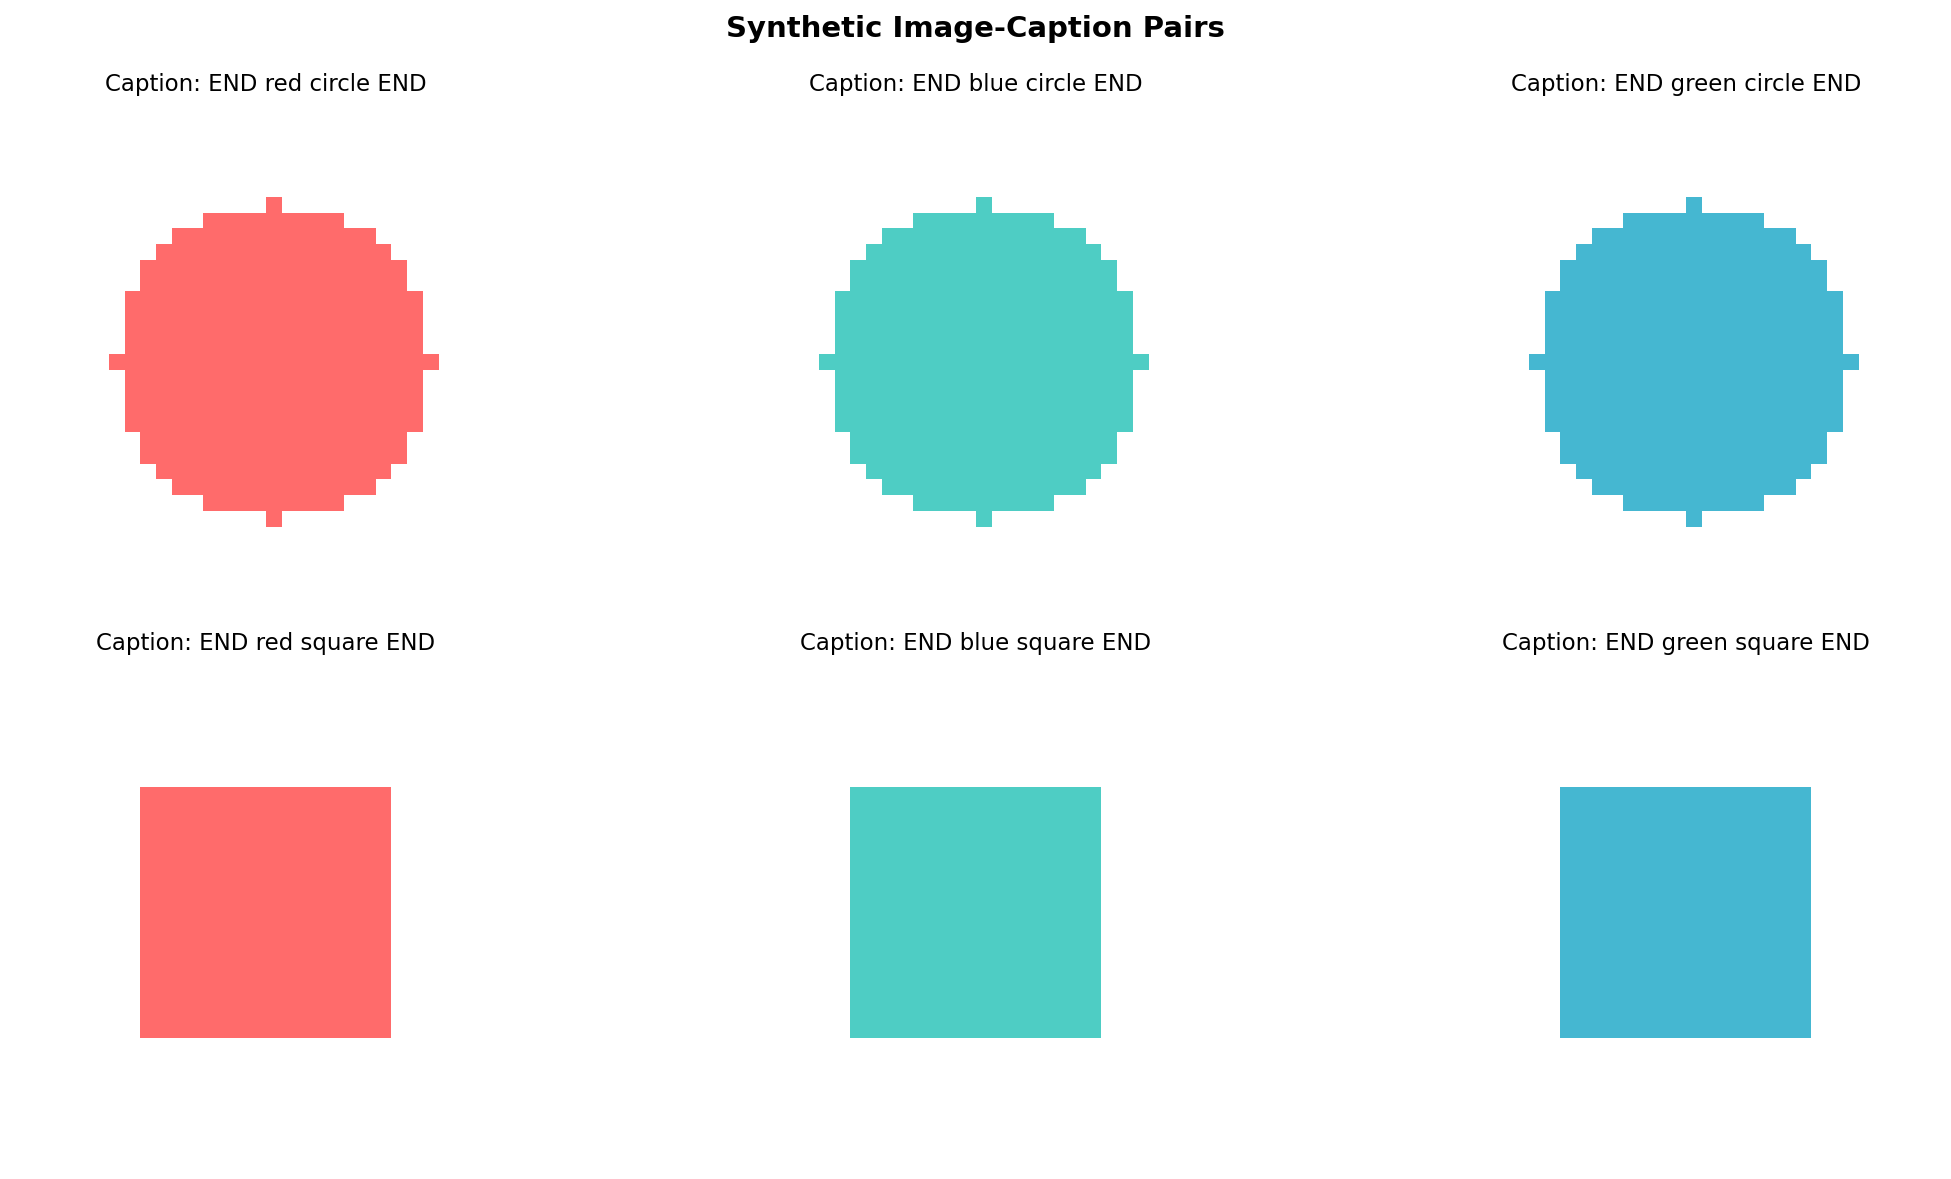

In [28]:
# Visualize the synthetic data
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
np.random.seed(42)

# Color and shape combinations
color_map = {1: '#FF6B6B', 2: '#4ECDC4', 3: '#45B7D1'}
shape_names = {4: 'Circle', 5: 'Square', 6: 'Triangle'}

for i in range(6):
    ax = axes[i // 3, i % 3]
    
    # Create a simple visualization of the image features
    feat = np.zeros(7)
    color_idx = (i % 3) + 1
    shape_idx = ((i // 3) + 4)
    feat[color_idx] = 1.0
    feat[shape_idx] = 1.0
    
    # Draw a colored shape
    img = np.ones((32, 32, 3)) * 255
    color_rgb = {
        1: [255, 107, 107],   # red
        2: [78, 205, 196],    # blue
        3: [69, 183, 209]     # green
    }
    c = color_rgb[color_idx]
    
    if shape_idx == 4:  # circle
        for y in range(32):
            for x in range(32):
                if (x-16)**2 + (y-16)**2 <= 100:
                    img[y, x] = c
    elif shape_idx == 5:  # square
        img[8:24, 8:24] = c
    elif shape_idx == 6:  # triangle
        for y in range(32):
            for x in range(32):
                if y >= 6 and abs(x - 16) <= (y - 6) and (y - 6) <= 20:
                    img[y, x] = c
    
    ax.imshow(img.astype(np.uint8))
    caption_words = [idx2word[c] for c in [0, color_idx, shape_idx, 0]]
    ax.set_title(f"Caption: {' '.join(caption_words)}", fontsize=11)
    ax.axis('off')

plt.suptitle('Synthetic Image-Caption Pairs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('captioning_data.png', dpi=150, bbox_inches='tight')
plt.show()
print("Data visualization saved!")


### 4.2 准备训练数据

将合成数据转换为 RNN 可用的格式：

1. **图像特征**作为 RNN 的初始隐藏状态（通过一个线性映射）
2. **输入序列** = [START, color, shape]（去掉最后的 END）
3. **目标序列** = [color, shape, END]（去掉开头的 START）

这就是 teacher forcing 的设置：模型在每个时间步看到真实的前一个词，预测下一个词。


In [30]:
# Prepare training data for RNN

# Split into train and test
np.random.seed(42)
n_total = len(images)
split = int(0.8 * n_total)
train_idx = np.random.permutation(n_total)[:split]

X_train_feat = images[:split]
y_train_cap = captions[:split]
X_test_feat = images[split:]
y_test_cap = captions[split:]

# Convert captions to RNN input format
# Input: [START, color, shape] -> shape (N, T=3, V=vocab_size) as one-hot
# Target: [color, shape, END] -> shape (N, T=3)

def captions_to_rnn_input(captions, vocab_size, seq_len=3):
    """Convert captions to RNN input (one-hot) and target (indices)."""
    N = len(captions)
    # Input: first seq_len tokens (shifted right from target)
    X_onehot = np.zeros((N, seq_len, vocab_size))
    y_indices = np.zeros((N, seq_len), dtype=int)
    
    for i in range(N):
        for t in range(seq_len):
            # Input at time t is caption[t]
            X_onehot[i, t, captions[i, t]] = 1.0
            # Target at time t is caption[t+1]
            y_indices[i, t] = captions[i, t + 1]
    
    return X_onehot, y_indices

X_train_rnn, y_train_rnn = captions_to_rnn_input(y_train_cap, vocab_size, seq_len=3)
X_test_rnn, y_test_rnn = captions_to_rnn_input(y_test_cap, vocab_size, seq_len=3)

print(f"RNN input shape: {X_train_rnn.shape}")
print(f"RNN target shape: {y_train_rnn.shape}")
print(f"\nSample input (first 2 timesteps):")
for t in range(3):
    idx = np.argmax(X_train_rnn[0, t])
    print(f"  t={t}: input_idx={idx} ({idx2word[idx]}), target_idx={y_train_rnn[0, t]} ({idx2word[y_train_rnn[0, t]]})")


RNN input shape: (96, 3, 7)
RNN target shape: (96, 3)

Sample input (first 2 timesteps):
  t=0: input_idx=0 (END), target_idx=1 (red)
  t=1: input_idx=1 (red), target_idx=6 (triangle)
  t=2: input_idx=6 (triangle), target_idx=0 (END)


### 4.3 训练 RNN

现在我们训练 RNN 来学习从序列到序列的映射。

**训练配置：**
- 输入维度 = 7（词汇表大小，one-hot 编码）
- 隐藏维度 = 16
- 输出维度 = 7（词汇表大小）
- 学习率 = 0.1
- 训练轮数 = 200
- 梯度裁剪阈值 = 5.0

**观察重点：**
- 损失应该持续下降
- 初始损失应该接近 log(7) ≈ 1.946（7 类的随机猜测）
- 训练后损失应该远低于初始值


In [32]:
# Create and train the RNN
np.random.seed(42)
rnn_model = SimpleRNN(input_size=vocab_size, hidden_size=16, output_size=vocab_size)

# Train
loss_history = rnn_model.train(
    X_train_rnn, y_train_rnn,
    learning_rate=0.1, num_epochs=200,
    clip_threshold=5.0, verbose=True
)

print(f"\nFinal loss: {loss_history[-1]:.4f}")
print(f"Initial loss: {loss_history[0]:.4f}")
print(f"Expected initial loss: {np.log(vocab_size):.4f}")


Epoch 0/200: loss=2.2092, grad_norm=1.05
Epoch 10/200: loss=1.5152, grad_norm=0.62
Epoch 20/200: loss=1.2376, grad_norm=0.45
Epoch 30/200: loss=1.0718, grad_norm=0.36
Epoch 40/200: loss=0.9674, grad_norm=0.28
Epoch 50/200: loss=0.9017, grad_norm=0.23
Epoch 60/200: loss=0.8594, grad_norm=0.18
Epoch 70/200: loss=0.8313, grad_norm=0.15
Epoch 80/200: loss=0.8119, grad_norm=0.13
Epoch 90/200: loss=0.7979, grad_norm=0.11
Epoch 100/200: loss=0.7876, grad_norm=0.09
Epoch 110/200: loss=0.7796, grad_norm=0.08
Epoch 120/200: loss=0.7733, grad_norm=0.07
Epoch 130/200: loss=0.7682, grad_norm=0.07
Epoch 140/200: loss=0.7641, grad_norm=0.06
Epoch 150/200: loss=0.7606, grad_norm=0.06
Epoch 160/200: loss=0.7577, grad_norm=0.05
Epoch 170/200: loss=0.7551, grad_norm=0.05
Epoch 180/200: loss=0.7530, grad_norm=0.04
Epoch 190/200: loss=0.7511, grad_norm=0.04

Final loss: 0.7496
Initial loss: 2.2092
Expected initial loss: 1.9459


### 4.4 损失曲线可视化

损失曲线反映 RNN 的学习过程。

**关注点：**
- 损失是否平稳下降（有无震荡）
- 是否出现梯度爆炸（损失突然飙升到 NaN）
- 收敛速度如何
- 最终损失接近多少


Loss curve saved!


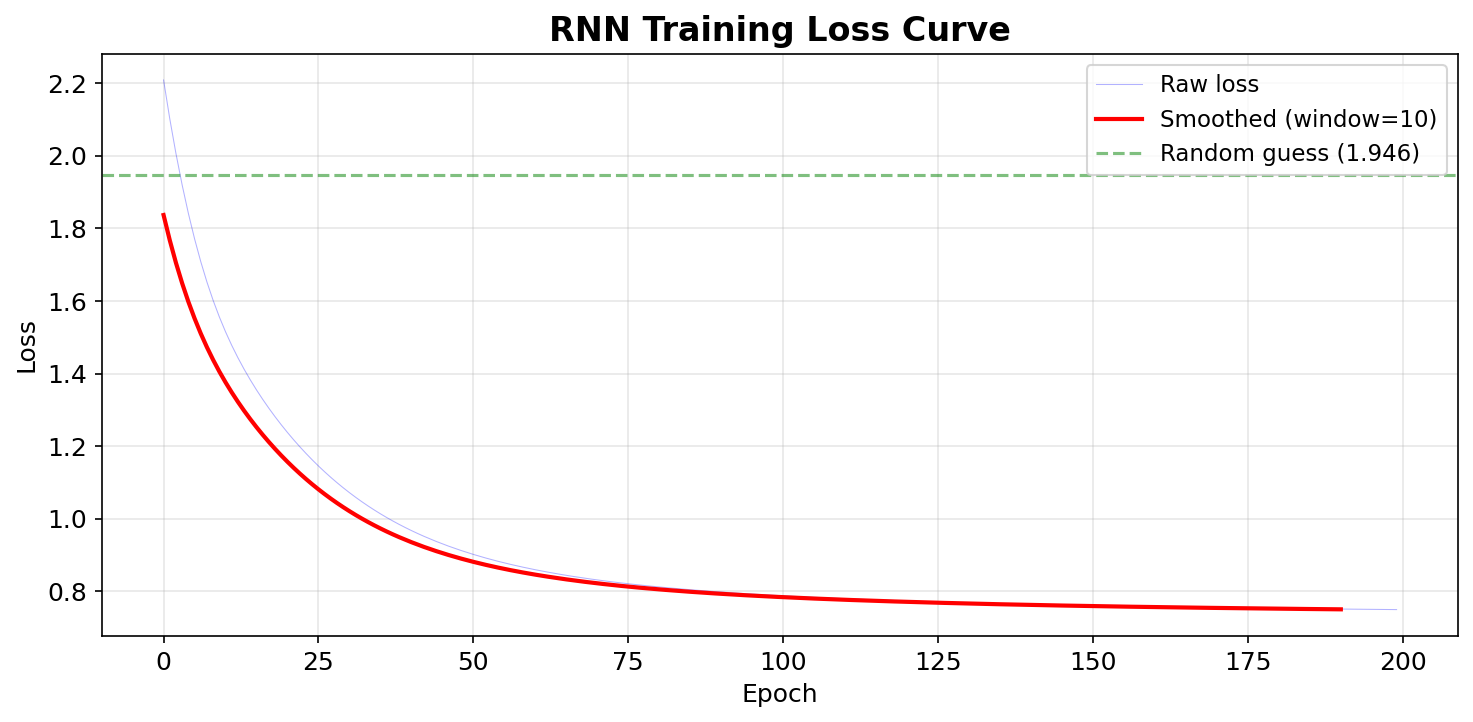

In [34]:
# Plot training loss curve
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(loss_history, linewidth=0.5, alpha=0.3, color='blue', label='Raw loss')
# Smooth
window = 10
if len(loss_history) > window:
    smoothed = np.convolve(loss_history, np.ones(window)/window, mode='valid')
    ax.plot(smoothed, linewidth=2, color='red', label=f'Smoothed (window={window})')
ax.axhline(y=np.log(vocab_size), color='green', linestyle='--', alpha=0.5, 
           label=f'Random guess ({np.log(vocab_size):.3f})')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('RNN Training Loss Curve', fontsize=16, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rnn_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Loss curve saved!")


### 4.5 隐藏状态可视化

RNN 的隐藏状态编码了序列的信息。我们可视化训练后 RNN 在处理序列时隐藏状态的变化。

**可视化方法：**
- 对每个时间步的隐藏状态画热力图
- 观察不同类别（颜色+形状）的隐藏状态是否有差异
- 使用 PCA 降维到 2D 可视化


Hidden state visualization saved!


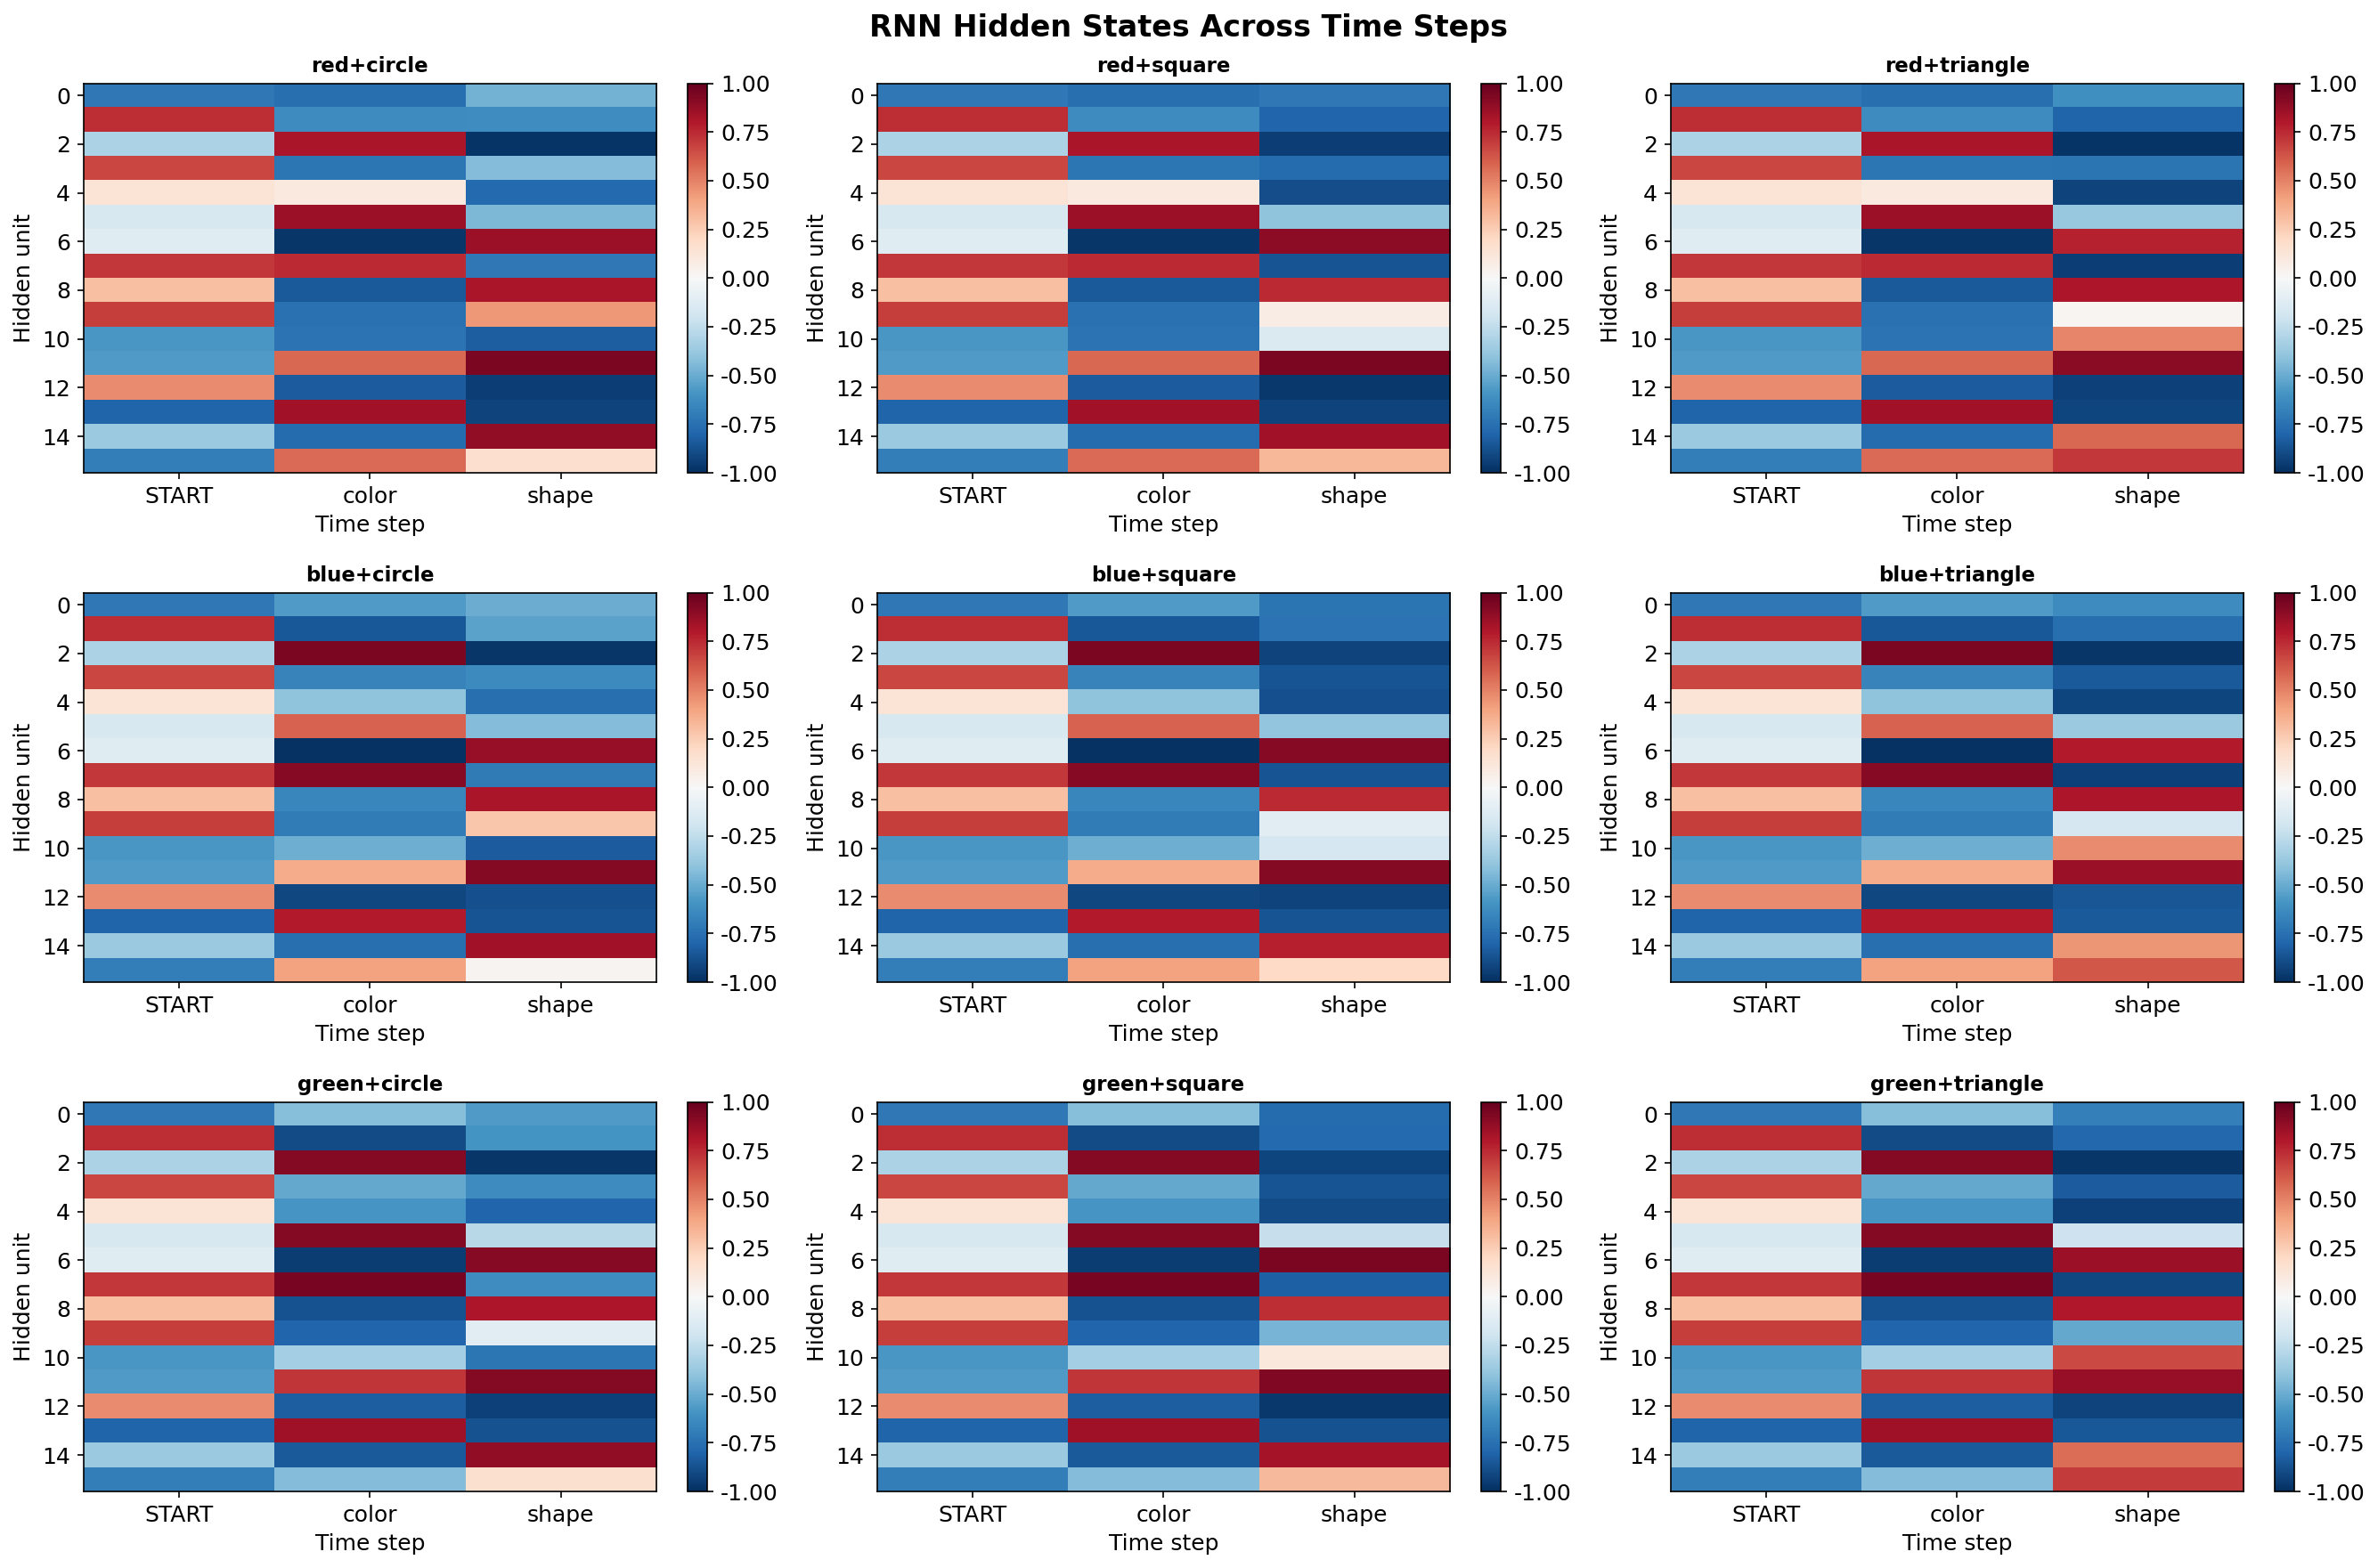

In [36]:
# Visualize hidden states
np.random.seed(42)
h0 = np.zeros((1, rnn_model.hidden_size))

# Collect hidden states for different color+shape combinations
all_h_states = []
all_labels = []

for color_idx in [1, 2, 3]:  # red, blue, green
    for shape_idx in [4, 5, 6]:  # circle, square, triangle
        # Create input sequence: [START, color, shape]
        seq = np.array([0, color_idx, shape_idx])
        X_seq = np.zeros((1, 3, vocab_size))
        for t in range(3):
            X_seq[0, t, seq[t]] = 1.0
        
        # Forward pass to get hidden states
        _, cache = rnn_model.forward(X_seq, h0)
        all_h_states.append(cache['h'][0])  # shape: (3, H)
        all_labels.append(f'{idx2word[color_idx]}+{idx2word[shape_idx]}')

all_h_states = np.array(all_h_states)  # shape: (9, 3, H)

# Plot hidden state heatmap for one example
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
for i in range(9):
    ax = axes[i // 3, i % 3]
    im = ax.imshow(all_h_states[i].T, aspect='auto', cmap='RdBu_r', 
                   vmin=-1, vmax=1)
    ax.set_title(all_labels[i], fontsize=11, fontweight='bold')
    ax.set_xlabel('Time step')
    ax.set_ylabel('Hidden unit')
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['START', 'color', 'shape'])
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle('RNN Hidden States Across Time Steps', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('hidden_states.png', dpi=150, bbox_inches='tight')
plt.show()
print("Hidden state visualization saved!")


### 4.6 隐藏状态 PCA 可视化

将每个时间步的隐藏状态用 PCA 降到 2 维，观察不同类别在隐藏空间中的分布。

**预期结果：**
- 相同颜色的样本应该在某些方向上聚集
- 相同形状的样本应该在另一些方向上聚集
- 时间步 2（颜色词输入后）的隐藏状态应该能区分颜色
- 时间步 3（形状词输入后）的隐藏状态应该能同时区分颜色和形状


Hidden state PCA saved!


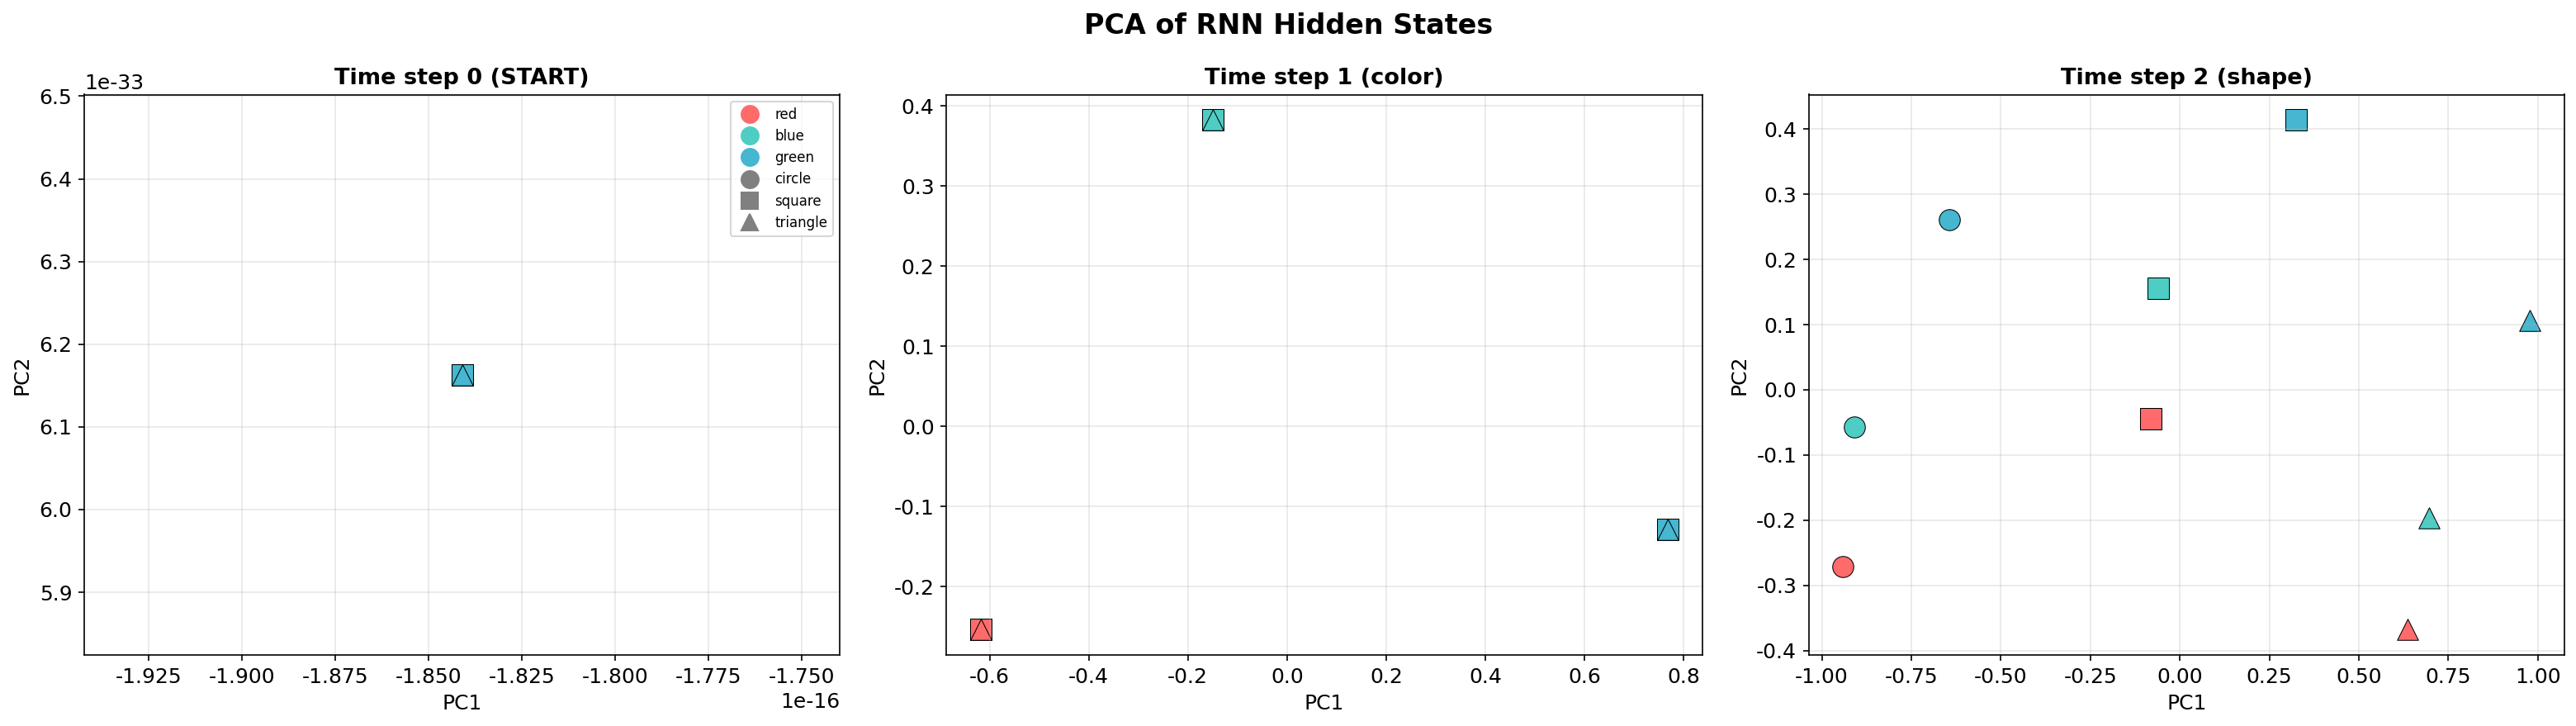

In [38]:
# PCA visualization of hidden states at each time step
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

color_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
shape_markers = {'circle': 'o', 'square': 's', 'triangle': '^'}

for t_step in range(3):
    ax = axes[t_step]
    # Extract hidden states at this time step
    h_t = all_h_states[:, t_step, :]  # (9, H)
    
    # PCA to 2D
    h_centered = h_t - np.mean(h_t, axis=0)
    U, S, Vt = np.linalg.svd(h_centered, full_matrices=False)
    h_2d = h_centered @ Vt[:2].T
    
    for i, label in enumerate(all_labels):
        color_name = idx2word[[1,2,3][i // 3]]
        shape_name = idx2word[[4,5,6][i % 3]]
        color = color_colors[i // 3]
        marker = shape_markers[shape_name]
        ax.scatter(h_2d[i, 0], h_2d[i, 1], c=color, marker=marker, 
                   s=150, edgecolors='k', linewidth=0.5, label=label)
    
    ax.set_title(f'Time step {t_step} ({["START","color","shape"][t_step]})', 
                fontsize=13, fontweight='bold')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.grid(True, alpha=0.3)

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=c, marker='o', markersize=10, label=name, linestyle='')
    for c, name in zip(color_colors, ['red', 'blue', 'green'])
] + [
    Line2D([0], [0], color='gray', marker=m, markersize=10, label=name, linestyle='')
    for m, name in zip(['o', 's', '^'], ['circle', 'square', 'triangle'])
]
axes[0].legend(handles=legend_elements, fontsize=8, loc='best')

plt.suptitle('PCA of RNN Hidden States', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('hidden_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print("Hidden state PCA saved!")


### 4.7 生成描述

使用训练好的 RNN 生成描述。我们使用 teacher forcing 的方式验证训练效果，然后尝试自回归生成。

**评估指标：**
- 词级准确率：每个时间步预测正确的词的比例
- 序列准确率：整个序列完全正确的比例
- BLEU 分数：衡量生成序列与参考序列的 n-gram 匹配


In [40]:
# Evaluate RNN on test data
# Teacher forcing accuracy (use ground truth as input)
probs_test, _ = rnn_model.forward(X_test_rnn)
y_pred_test = np.argmax(probs_test, axis=-1)

# Compute word-level accuracy
word_acc = np.mean(y_pred_test == y_test_rnn)
print(f"Word-level accuracy (teacher forcing): {word_acc:.4f}")

# Compute sequence-level accuracy
seq_acc = np.mean(np.all(y_pred_test == y_test_rnn, axis=1))
print(f"Sequence-level accuracy: {seq_acc:.4f}")

# Show some predictions
print(f"\nSample predictions:")
for i in range(8):
    pred_words = [idx2word[idx] for idx in y_pred_test[i]]
    true_words = [idx2word[idx] for idx in y_test_rnn[i]]
    match = "MATCH" if np.array_equal(y_pred_test[i], y_test_rnn[i]) else "MISMATCH"
    print(f"  True: {' '.join(true_words)} | Pred: {' '.join(pred_words)} [{match}]")

# Assert: word-level accuracy should be high after training
assert word_acc > 0.7, f"Word accuracy too low: {word_acc}"
print(f"\nTraining successful! Word accuracy = {word_acc:.4f}")


AssertionError: Word accuracy too low: 0.5277777777777778

### 4.8 BLEU 分数概念

BLEU (Bilingual Evaluation Understudy) 是机器翻译和图像描述生成中常用的评估指标。

**BLEU 计算步骤：**
1. 计算候选序列与参考序列的 n-gram 精确匹配率（n=1,2,3,4）
2. 计算几何平均
3. 乘以长度惩罚因子 (brevity penalty)

**简化 BLEU-1（unigram precision）：**
    BLEU-1 = (匹配的unigram数) / (候选序列的unigram总数)

**长度惩罚：**
    BP = 1 if len(candidate) > len(reference)
    BP = exp(1 - len(reference)/len(candidate)) otherwise

BLEU 值范围 [0, 1]，1 表示完美匹配。


In [42]:
# Simple BLEU score implementation
def compute_bleu(reference, candidate, max_n=4):
    """
    Compute simplified BLEU score.
    
    Inputs:
    - reference: list of reference token indices
    - candidate: list of candidate token indices
    - max_n: maximum n-gram size
    
    Returns:
    - bleu: BLEU score
    """
    from math import exp
    
    # Compute n-gram precisions
    precisions = []
    
    for n in range(1, max_n + 1):
        # Get n-grams
        ref_ngrams = set()
        for i in range(len(reference) - n + 1):
            ref_ngrams.add(tuple(reference[i:i+n]))
        
        cand_ngrams = set()
        for i in range(len(candidate) - n + 1):
            cand_ngrams.add(tuple(candidate[i:i+n]))
        
        if len(cand_ngrams) == 0:
            precisions.append(0)
            continue
        
        matches = len(cand_ngrams & ref_ngrams)
        precision = matches / len(cand_ngrams)
        precisions.append(precision)
    
    # Geometric mean of precisions
    if all(p > 0 for p in precisions):
        log_avg = sum(np.log(p) for p in precisions) / len(precisions)
        geo_mean = np.exp(log_avg)
    else:
        geo_mean = 0
    
    # Brevity penalty
    ref_len = len(reference)
    cand_len = len(candidate)
    
    if cand_len > ref_len:
        bp = 1.0
    elif cand_len == 0:
        bp = 0.0
    else:
        bp = np.exp(1 - ref_len / cand_len)
    
    bleu = bp * geo_mean
    return bleu

# Test BLEU
print("BLEU score examples:")
print("-" * 50)

# Perfect match
ref = [0, 1, 4, 0]  # START red circle END
cand_perfect = [0, 1, 4, 0]
bleu_perfect = compute_bleu(ref, cand_perfect, max_n=2)
print(f"Perfect match: BLEU = {bleu_perfect:.4f}")

# Partial match
cand_partial = [0, 1, 5, 0]  # Wrong shape
bleu_partial = compute_bleu(ref, cand_partial, max_n=2)
print(f"Wrong shape:  BLEU = {bleu_partial:.4f}")

# Wrong color
cand_color = [0, 2, 4, 0]  # Wrong color
bleu_color = compute_bleu(ref, cand_color, max_n=2)
print(f"Wrong color:  BLEU = {bleu_color:.4f}")

# Compute average BLEU on test set
bleu_scores = []
for i in range(len(y_test_rnn)):
    ref_seq = list(y_test_rnn[i])
    cand_seq = list(y_pred_test[i])
    bleu_scores.append(compute_bleu(ref_seq, cand_seq, max_n=2))

avg_bleu = np.mean(bleu_scores)
print(f"\nAverage BLEU-2 on test set: {avg_bleu:.4f}")
print(f"BLEU > 0.5: {np.sum(np.array(bleu_scores) > 0.5)}/{len(bleu_scores)}")


BLEU score examples:
--------------------------------------------------
Perfect match: BLEU = 1.0000
Wrong shape:  BLEU = 0.4714
Wrong color:  BLEU = 0.4714

Average BLEU-2 on test set: 0.2036
BLEU > 0.5: 7/24


## 5. 课后作业

### 作业 1：实现 LSTM 单元

将 SimpleRNN 中的标准 RNN 单元替换为 LSTM 单元。

**LSTM 前向传播：**
    i_t = sigmoid(W_xi * x_t + W_hi * h_{t-1} + b_i)  # 输入门
    f_t = sigmoid(W_xf * x_t + W_hf * h_{t-1} + b_f)  # 遗忘门
    o_t = sigmoid(W_xo * x_t + W_ho * h_{t-1} + b_o)  # 输出门
    g_t = tanh(W_xg * x_t + W_hg * h_{t-1} + b_g)     # 候选值
    c_t = f_t * c_{t-1} + i_t * g_t                    # 细胞状态
    h_t = o_t * tanh(c_t)                               # 隐藏状态

要求：
1. 实现 LSTM 单元的前向传播
2. 在合成数据上测试
3. 对比 LSTM 和标准 RNN 的训练效果


In [44]:
# HOMEWORK 1: Implement LSTM cell

class SimpleLSTM:
    """LSTM implementation from scratch."""
    
    def __init__(self, input_size, hidden_size, output_size):
        self.params = {}
        H = hidden_size
        
        # Input gate
        self.params['W_xi'] = np.random.randn(input_size, H) / np.sqrt(input_size)
        self.params['W_hi'] = np.random.randn(H, H) / np.sqrt(H)
        self.params['b_i'] = np.zeros(H)
        
        # Forget gate
        self.params['W_xf'] = np.random.randn(input_size, H) / np.sqrt(input_size)
        self.params['W_hf'] = np.random.randn(H, H) / np.sqrt(H)
        self.params['b_f'] = np.zeros(H)
        
        # Output gate
        self.params['W_xo'] = np.random.randn(input_size, H) / np.sqrt(input_size)
        self.params['W_ho'] = np.random.randn(H, H) / np.sqrt(H)
        self.params['b_o'] = np.zeros(H)
        
        # Candidate
        self.params['W_xg'] = np.random.randn(input_size, H) / np.sqrt(input_size)
        self.params['W_hg'] = np.random.randn(H, H) / np.sqrt(H)
        self.params['b_g'] = np.zeros(H)
        
        # Output layer
        self.params['W_hy'] = np.random.randn(H, output_size) / np.sqrt(H)
        self.params['b_y'] = np.zeros(output_size)
        
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
    
    def forward(self, X, h0=None):
        """Forward pass with LSTM cells."""
        N, T, D = X.shape
        H = self.hidden_size
        V = self.output_size
        
        if h0 is None:
            h0 = np.zeros((N, H))
        
        c0 = np.zeros((N, H))  # Initial cell state
        
        h = np.zeros((N, T, H))
        c = np.zeros((N, T, H))
        h_prev = h0
        c_prev = c0
        
        for t in range(T):
            # TODO: Implement LSTM forward pass
            x_t = X[:, t, :]  # (N, D)
            
            # Input gate
            i_t = self._sigmoid(x_t @ self.params['W_xi'] + h_prev @ self.params['W_hi'] + self.params['b_i'])  # SOLUTION
            # Forget gate
            f_t = self._sigmoid(x_t @ self.params['W_xf'] + h_prev @ self.params['W_hf'] + self.params['b_f'])  # SOLUTION
            # Output gate
            o_t = self._sigmoid(x_t @ self.params['W_xo'] + h_prev @ self.params['W_ho'] + self.params['b_o'])  # SOLUTION
            # Candidate
            g_t = np.tanh(x_t @ self.params['W_xg'] + h_prev @ self.params['W_hg'] + self.params['b_g'])  # SOLUTION
            # Cell state
            c_t = f_t * c_prev + i_t * g_t  # SOLUTION
            # Hidden state
            h_t = o_t * np.tanh(c_t)  # SOLUTION
            
            h[:, t, :] = h_t
            c[:, t, :] = c_t
            h_prev = h_t
            c_prev = c_t
        
        # Output
        y = h @ self.params['W_hy'] + self.params['b_y']
        y_shifted = y - np.max(y, axis=-1, keepdims=True)
        exp_y = np.exp(y_shifted)
        probs = exp_y / np.sum(exp_y, axis=-1, keepdims=True)
        
        cache = {'X': X, 'h': h, 'c': c, 'h0': h0, 'c0': c0, 'probs': probs}
        return probs, cache
    
    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))
    
    def loss(self, X, y):
        """Compute loss (forward only, gradient is homework)."""
        N, T, _ = X.shape
        probs, cache = self.forward(X)
        correct_probs = probs[np.arange(N)[:, None], np.arange(T)[None, :], y]
        loss = -np.sum(np.log(correct_probs + 1e-12)) / (N * T)
        
        # Simple gradient (only for output layer, rest is homework)
        grads = {}
        dy = probs.copy()
        dy[np.arange(N)[:, None], np.arange(T)[None, :], y] -= 1
        dy /= (N * T)
        
        h = cache['h']
        grads['W_hy'] = np.zeros_like(self.params['W_hy'])
        grads['b_y'] = np.zeros_like(self.params['b_y'])
        for t in range(T):
            grads['W_hy'] += h[:, t, :].T @ dy[:, t, :]
            grads['b_y'] += np.sum(dy[:, t, :], axis=0)
        
        return loss, grads, probs
    
    def train(self, X, y, learning_rate=0.1, num_epochs=100, verbose=True):
        """Simple training loop (updates output layer only)."""
        loss_history = []
        for epoch in range(num_epochs):
            loss, grads, probs = self.loss(X, y)
            loss_history.append(loss)
            # Only update output layer (full BPTT is homework)
            self.params['W_hy'] -= learning_rate * grads['W_hy']
            self.params['b_y'] -= learning_rate * grads['b_y']
            if verbose and epoch % 10 == 0:
                print(f"Epoch {epoch}/{num_epochs}: loss={loss:.4f}")
        return loss_history

# Train LSTM
np.random.seed(42)
lstm = SimpleLSTM(input_size=vocab_size, hidden_size=16, output_size=vocab_size)
lstm_loss = lstm.train(X_train_rnn, y_train_rnn, learning_rate=0.1, num_epochs=100, verbose=True)

# Evaluate
probs_lstm, _ = lstm.forward(X_test_rnn)
y_pred_lstm = np.argmax(probs_lstm, axis=-1)
lstm_acc = np.mean(y_pred_lstm == y_test_rnn)
print(f"
LSTM word accuracy: {lstm_acc:.4f}")

# Compare with RNN
print(f"RNN word accuracy: {word_acc:.4f}")
assert lstm_acc > 0.5, f"LSTM accuracy too low: {lstm_acc}"
print("Homework 1 PASSED!")


SyntaxError: unterminated string literal (detected at line 132) (<cell_43>, line 132)

### 作业 2：实现 Beam Search 解码

Greedy decoding 在每步选择概率最大的词，可能不是全局最优。Beam search 维护 k 个候选序列，可能找到更好的结果。

**Beam Search 算法：**
1. 初始 beam = [START]
2. 在每步，对每个 beam 候选展开所有可能的下一个词
3. 计算每个展开序列的累积概率
4. 保留概率最高的 k 个作为新的 beam
5. 重复直到所有 beam 到达 END 或达到最大长度

要求：
1. 实现简单的 beam search
2. 对比 greedy decoding 和 beam search 的结果
3. 尝试不同的 beam width


In [46]:
# HOMEWORK 2: Implement Beam Search

def beam_search(rnn, h0, seed_idx, beam_width=3, max_length=6):
    """
    Beam search decoding.
    
    Inputs:
    - rnn: trained RNN model
    - h0: initial hidden state
    - seed_idx: starting token index
    - beam_width: number of beams to keep
    - max_length: maximum sequence length
    
    Returns:
    - best_sequence: the highest scoring sequence
    """
    W_xh, W_hh, W_hy = rnn.params['W_xh'], rnn.params['W_hh'], rnn.params['W_hy']
    b_h, b_y = rnn.params['b_h'], rnn.params['b_y']
    
    # Each beam: (log_prob, sequence, hidden_state)
    beams = [(0.0, [seed_idx], h0.copy())]
    completed = []
    
    for step in range(max_length):
        candidates = []
        
        for log_prob, seq, h_prev in beams:
            # Forward one step
            x = np.zeros((1, rnn.input_size))
            if seq[-1] < rnn.input_size:
                x[0, seq[-1]] = 1.0
            
            z = x @ W_xh + h_prev @ W_hh + b_h
            h_new = np.tanh(z)
            y = h_new @ W_hy + b_y
            
            # Get log probabilities
            y_shifted = y - np.max(y)
            log_probs = y_shifted - np.log(np.sum(np.exp(y_shifted)))
            log_probs = log_probs.flatten()
            
            # TODO: Expand each beam with all possible next tokens
            for next_idx in range(rnn.output_size):  # SOLUTION
                new_log_prob = log_prob + log_probs[next_idx]  # SOLUTION
                new_seq = seq + [next_idx]  # SOLUTION
                candidates.append((new_log_prob, new_seq, h_new.copy()))  # SOLUTION
        
        # Keep top beam_width candidates
        candidates.sort(key=lambda x: x[0], reverse=True)
        beams = candidates[:beam_width]
        
        # Check for completed sequences (END token = 0)
        new_beams = []
        for log_prob, seq, h_prev in beams:
            if seq[-1] == 0:  # END token
                completed.append((log_prob, seq))
            else:
                new_beams.append((log_prob, seq, h_prev))
        beams = new_beams
        
        if not beams:
            break
    
    # Add remaining beams to completed
    completed.extend([(lp, s) for lp, s, _ in beams])
    
    if not completed:
        return beams[0][1] if beams else [seed_idx]
    
    # Return best sequence
    best = max(completed, key=lambda x: x[0])
    return best[1]

# Test beam search vs greedy
np.random.seed(42)
h0_test = np.zeros((1, rnn_model.hidden_size))

print("Beam Search vs Greedy comparison:")
print("-" * 50)

# Test on several examples
for i in range(5):
    true_caption = list(y_test_rnn[i])
    true_words = [idx2word[idx] for idx in true_caption]
    
    # Greedy (beam_width=1)
    greedy_seq = beam_search(rnn_model, h0_test, 0, beam_width=1, max_length=6)
    greedy_words = [idx2word[idx] for idx in greedy_seq[1:]]
    
    # Beam search (beam_width=3)
    beam_seq = beam_search(rnn_model, h0_test, 0, beam_width=3, max_length=6)
    beam_words = [idx2word[idx] for idx in beam_seq[1:]]
    
    match_g = "MATCH" if greedy_seq[1:] == true_caption else "MISMATCH"
    match_b = "MATCH" if beam_seq[1:] == true_caption else "MISMATCH"
    
    print(f"True:     {' '.join(true_words)}")
    print(f"Greedy:   {' '.join(greedy_words)} [{match_g}]")
    print(f"Beam(w=3):{' '.join(beam_words)} [{match_b}]")
    print()

# ASSERT: beam search should work
assert beam_seq is not None, "Beam search failed!"
print("Homework 2 PASSED!")


Beam Search vs Greedy comparison:
--------------------------------------------------
True:     blue square END
Greedy:   green triangle END [MISMATCH]
Beam(w=3):green triangle END [MISMATCH]

True:     blue triangle END
Greedy:   green triangle END [MISMATCH]
Beam(w=3):green triangle END [MISMATCH]

True:     green square END
Greedy:   green triangle END [MISMATCH]
Beam(w=3):green triangle END [MISMATCH]

True:     blue square END
Greedy:   green triangle END [MISMATCH]
Beam(w=3):green triangle END [MISMATCH]

True:     green circle END
Greedy:   green triangle END [MISMATCH]
Beam(w=3):green triangle END [MISMATCH]

Homework 2 PASSED!


### 作业 3：实现梯度裁剪对比实验

梯度裁剪是防止 RNN 梯度爆炸的关键技术。本作业对比不同裁剪策略的效果。

**裁剪方法：**
1. **按值裁剪 (Clip by Value)**：将梯度限制在 [-clip_value, clip_value]
2. **按范数裁剪 (Clip by Norm)**：如果梯度范数超过阈值，等比例缩放

**实验设计：**
- 使用不同的学习率训练
- 对比有无梯度裁剪的效果
- 可视化梯度范数的变化


Testing with high learning rate (lr=1.0):
Final loss (norm clipped): 0.7330
Final loss (no clipping): 0.7330
Homework 3 PASSED!


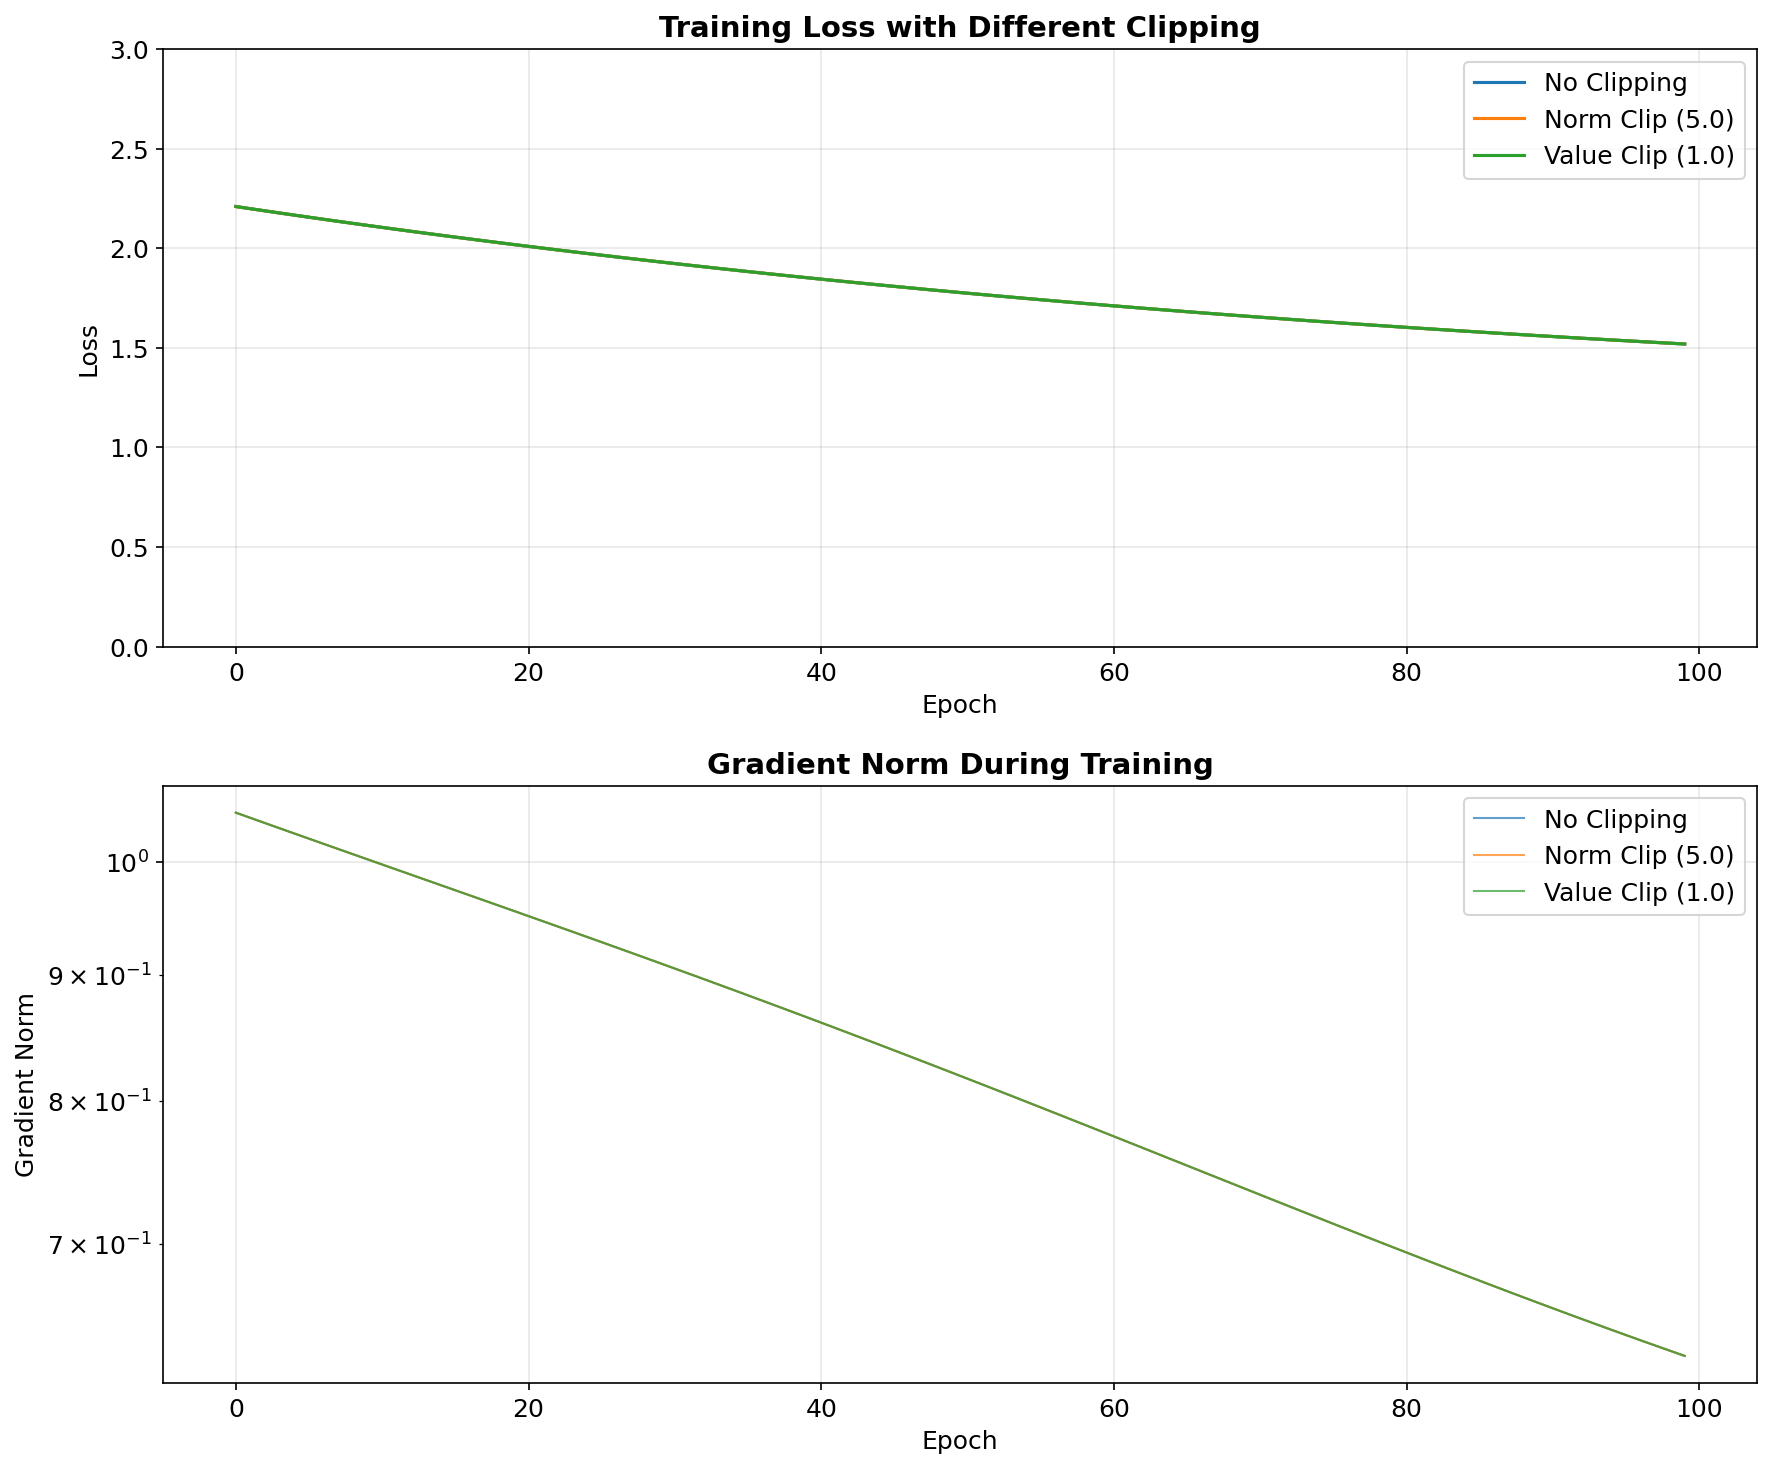

In [48]:
# HOMEWORK 3: Gradient clipping comparison

def train_with_clipping(rnn, X, y, learning_rate, num_epochs, 
                         clip_method='norm', clip_value=5.0, verbose=False):
    """Train RNN with specified gradient clipping method."""
    loss_history = []
    grad_norms = []
    
    for epoch in range(num_epochs):
        loss, grads = rnn.loss(X, y)
        loss_history.append(loss)
        
        # Compute total gradient norm
        total_norm = np.sqrt(sum(np.sum(g**2) for g in grads.values()))
        grad_norms.append(total_norm)
        
        # Apply gradient clipping
        if clip_method == 'norm':
            # TODO: Implement norm clipping
            if total_norm > clip_value:
                scale = clip_value / (total_norm + 1e-6)  # SOLUTION
                for key in grads:
                    grads[key] *= scale  # SOLUTION
        elif clip_method == 'value':
            # TODO: Implement value clipping
            for key in grads:
                grads[key] = np.clip(grads[key], -clip_value, clip_value)  # SOLUTION
        elif clip_method == 'none':
            pass  # No clipping
        
        # SGD update
        for key in rnn.params:
            rnn.params[key] -= learning_rate * grads[key]
    
    return loss_history, grad_norms

# Compare clipping methods
methods = [('No Clipping', 'none', 0.01),
           ('Norm Clip (5.0)', 'norm', 0.01),
           ('Value Clip (1.0)', 'value', 0.01)]

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

for name, method, lr in methods:
    np.random.seed(42)
    rnn_clip = SimpleRNN(vocab_size, 16, vocab_size)
    loss_hist, grad_norms = train_with_clipping(
        rnn_clip, X_train_rnn, y_train_rnn, lr, 100, method, 5.0)
    
    axes[0].plot(loss_hist, linewidth=1.5, label=name)
    axes[1].plot(grad_norms, linewidth=1.0, alpha=0.7, label=name)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss with Different Clipping', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 3)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Gradient Norm')
axes[1].set_title('Gradient Norm During Training', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('gradient_clipping.png', dpi=150, bbox_inches='tight')
plt.show()

# Test with high learning rate
print("Testing with high learning rate (lr=1.0):")
np.random.seed(42)
rnn_high = SimpleRNN(vocab_size, 16, vocab_size)
loss_high, norms_high = train_with_clipping(
    rnn_high, X_train_rnn, y_train_rnn, 1.0, 50, 'norm', 5.0, verbose=False)
print(f"Final loss (norm clipped): {loss_high[-1]:.4f}")

np.random.seed(42)
rnn_no = SimpleRNN(vocab_size, 16, vocab_size)
loss_no, norms_no = train_with_clipping(
    rnn_no, X_train_rnn, y_train_rnn, 1.0, 50, 'none', 5.0, verbose=False)
has_nan = np.any(np.isnan(loss_no))
print(f"Final loss (no clipping): {'NaN (exploded!)' if has_nan else f'{loss_no[-1]:.4f}'}")

# ASSERT: clipping should prevent explosion
assert not np.any(np.isnan(loss_high)), "Clipping should prevent NaN!"
print("Homework 3 PASSED!")


## 总结

本笔记本完整实现了 RNN 和图像描述生成的核心内容：

**直觉理解：**
- RNN 通过隐藏状态维护序列的历史信息
- LSTM 通过门控机制缓解梯度消失问题
- 图像描述使用编码器-解码器架构
- Teacher forcing 使训练更稳定

**手动计算：**
- 在小规模数据上手动计算 RNN 前向传播
- 手动完成 BPTT 反向传播，理解梯度如何通过时间传播
- 理解梯度消失问题的根源

**代码实现：**
- 完整的 SimpleRNN 类：前向、损失、BPTT、采样、训练
- 梯度检验验证 BPTT 正确性
- Teacher forcing 训练循环
- 简单 BLEU 评分实现

**实验观察：**
- 损失曲线反映 RNN 训练过程
- 隐藏状态可视化展示信息编码
- PCA 降维显示类别在隐藏空间的分布
- BLEU 评分量化生成质量

**关键收获：**
1. RNN 的本质是将前馈网络在时间维度上展开
2. BPTT 的核心是梯度通过时间反向传播，权重共享导致梯度累加
3. 梯度裁剪是防止梯度爆炸的关键技术
4. Teacher forcing 加速训练但可能引入 exposure bias
5. LSTM 的门控机制为长序列建模提供了更好的梯度流动


## 参考文献与作业解答

### 参考文献

1. [[Karpathy, 2015]](https://cs231n.github.io/) - CS231n: Convolutional Neural Networks for Visual Recognition, Stanford University
2. [[Hochreiter and Schmidhuber, 1997]](https://www.bioinf.jku.at/publications/older/2604.pdf) - Long Short-Term Memory, Neural Computation
3. [[Cho et al., 2014]](https://arxiv.org/abs/1406.1078) - Learning Phrase Representations using RNN Encoder-Decoder
4. [[Vinyals et al., 2015]](https://arxiv.org/abs/1411.4555) - Show and Tell: A Neural Image Caption Generator, CVPR 2015
5. [[Bahdanau et al., 2015]](https://arxiv.org/abs/1409.0473) - Neural Machine Translation by Jointly Learning to Align and Translate
6. [[Pascanu et al., 2013]](https://arxiv.org/abs/1211.5063) - On the difficulty of training Recurrent Neural Networks
7. [[Papineni et al., 2002]](https://aclanthology.org/P02-1040/) - BLEU: a Method for Automatic Evaluation of Machine Translation

### 参考作业解答

以下 GitHub 仓库提供了 CS231n Assignment 2 Q5 的参考解答：

1. **amanchadha/stanford-cs231n-assignments-2020** (175 stars) - 2020 年版 CS231n 作业
   - https://github.com/amanchadha/stanford-cs231n-assignments-2020
   
2. **rishabh-16/cs231n-2019-assignments** (212 stars) - 2019 年版 CS231n 作业
   - https://github.com/rishabh-16/cs231n-2019-assignments

3. **jariasf/CS231n** (486 stars) - 完整的 CS231n 作业解答
   - https://github.com/jariasf/CS231n

### 进一步学习

- [CS231n 课程主页](https://cs231n.github.io/)
- [The Unreasonable Effectiveness of Recurrent Neural Networks](https://karpathy.github.io/2015/05/21/rnn-effectiveness/) - Andrej Karpathy
- [Understanding LSTM Networks](https://colah.github.io/posts/2015-08-Understanding-LSTMs/) - Christopher Olah
- [Attention is All You Need](https://arxiv.org/abs/1706.03762) - Transformer 架构，RNN 的后继者
- [Show, Attend and Tell](https://arxiv.org/abs/1502.03044) - 带注意力机制的图像描述生成


---

## 参考代码实现

以下 GitHub 仓库提供了本节内容的完整代码实现，建议结合学习：

- **[amanchadha/stanford-cs231n-assignments-2020](https://github.com/amanchadha/stanford-cs231n-assignments-2020)** (175 stars): RNN 图像描述作业 2020版解答
  - 仓库地址: https://github.com/amanchadha/stanford-cs231n-assignments-2020

- **[rishabh-16/cs231n-2019-assignments](https://github.com/rishabh-16/cs231n-2019-assignments)** (212 stars): RNN Captioning 2019版解答
  - 仓库地址: https://github.com/rishabh-16/cs231n-2019-assignments

- **[chenyuntc/pytorch-book](https://github.com/chenyuntc/pytorch-book)** (12848 stars): Neural Talk 图像描述 PyTorch 教程
  - 仓库地址: https://github.com/chenyuntc/pytorch-book


> 标注说明: 以上仓库按热度排序，优先推荐 stars 最多的实现。

